In [1]:
# installed gradio 6 from pip at some point and some deps were installed, but uninstalled (deps didn't uninstall) and switched back to the conda version

# Import

In [2]:
import sys, os, re, subprocess, datetime, contextlib, gzip, shutil, tempfile, json, requests, traceback, copy, pymol2, time, zipfile
import pandas as pd
import molviewspec as mvs
from pathlib import Path
import numpy as np
from Bio import SeqIO
import gradio as gr
from gradio_client import Client
from sklearn.metrics import average_precision_score
from matplotlib.colors import to_hex
from rcsbapi.search import AttributeQuery, Sort
# import rcsbapi

sys.path.append("..")
from predict import \
get_cif, Cif, CifFileWriter, get_clean_pdb, \
Pocket, get_pockets, get_pockets_features, \
get_pdb_features, prepare_data, model, \
get_unfiltered_pathways, get_filtered_pathways, paultol_palette

/home/fnerin/miniconda3/envs/allopockets/lib/python3.11/site-packages/autogluon/common/utils/utils.py:78: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/home/fnerin/miniconda3/envs/allopockets/lib/python3.11/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


In [3]:
# cif = Cif("8wjx", "8wjx/8wjx_updated.cif.gz")
# set(pd.DataFrame(cif.cif.data["_pdbx_unobs_or_zero_occ_residues"], dtype=str).query("label_asym_id == 'E' and PDB_model_num == '1'").label_seq_id.astype(int))

# Databases

In [4]:
from playhouse.apsw_ext import APSWDatabase, Model, TextField, CompositeKey, fn

In [5]:
db = APSWDatabase('allopockets.db')

In [6]:
class BaseModel(Model):
    class Meta:
        database = db

class Structure(BaseModel):
    pdb_id = TextField()
    chains = TextField()
    workdir = TextField()
    
    class Meta:
        primary_key = CompositeKey('pdb_id', 'chains')

class Local(BaseModel):
    pdb_id = TextField()
    chains = TextField()
    workdir = TextField()
    
    class Meta:
        primary_key = CompositeKey('pdb_id', 'chains')

class Job(BaseModel):
    jobid = TextField(primary_key=True)
    pdb_id = TextField()
    chains = TextField()
    workdir = TextField()
    state = TextField(null=True) # NULL=running, "OK"=done, else error message


class Ensemble(BaseModel):
    jobid = TextField(primary_key=True)
    state = TextField(null=True) # NULL=running, "OK"=done, else error message

# Initialize tables
db.connect()
db.create_tables([Structure, Local, Job, Ensemble])

In [7]:
pd.DataFrame(list(Structure.select().dicts()))

,pdb_id,chains,workdir
0,6jpa,C,6jpa/6jpa-C-2025-07-29-13-45-51-725726-nta5oxe...
1,2ldr,A,2ldr/2ldr-A-2025-07-29-13-50-02-571655-nta5oxe...
2,6jpa_testciffrompdb_1800427881535255,B,6jpa_testciffrompdb_1800427881535255/6jpa_test...
3,6jpa_testciffrompdb_7903216909225615,B,6jpa_testciffrompdb_7903216909225615/6jpa_test...
4,8aq6,G,8aq6/8aq6-G-2025-07-31-13-05-37-586371-inqfp74...
5,1sl6,A,1sl6/1sl6-A-2025-08-07-18-11-25-102719-2e82mfr...
6,2it6,A,2it6/2it6-A-2025-08-12-11-48-15-042722-kjv8x8m...
7,7nl6,A,7nl6/7nl6-A-2025-08-12-11-53-10-201292-kjv8x8m...
8,8v81,A,8v81/8v81-A-2025-08-27-14-16-04-043665-riaxpk6...
9,2ldo,A,2ldo/2ldo-A-2025-09-01-12-20-51-000190-zvoklkbfus


In [8]:
pd.DataFrame(list(Job.select().dicts()))

,jobid,pdb_id,chains,workdir,state
0,8qni-A-2025-11-28-16-28-19-793755-5qe6jt0fir9,8qni,A,8qni/8qni-A-2025-11-28-16-28-19-793755-5qe6jt0...,OK
1,7sns-A-2025-12-02-17-58-19-934744-338592269176...,7sns,A,7sns/7sns-A-2025-12-02-17-58-19-934744-3385922...,None
2,7sns-A-2025-12-02-18-06-14-777311-ybh4fmvor,7sns,A,7sns/7sns-A-2025-12-02-18-06-14-777311-ybh4fmvor,"Traceback (most recent call last):\n File ""/t..."
3,7sns-A-2025-12-02-18-23-47-232585-ye502nvvavp,7sns,A,7sns/7sns-A-2025-12-02-18-23-47-232585-ye502nv...,"Traceback (most recent call last):\n File ""/t..."
4,7sns-A-2025-12-02-18-27-04-314707-hzlbr55dvn4,7sns,A,7sns/7sns-A-2025-12-02-18-27-04-314707-hzlbr55...,"Traceback (most recent call last):\n File ""/t..."
5,7sns-A-2025-12-02-18-39-14-855648--15934311516...,7sns,A,7sns/7sns-A-2025-12-02-18-39-14-855648--159343...,"Traceback (most recent call last):\n File ""/t..."
6,7snw-A-2025-12-02-18-39-17-277045--32965512611...,7snw,A,7snw/7snw-A-2025-12-02-18-39-17-277045--329655...,"Traceback (most recent call last):\n File ""/t..."
7,7snt-A-2025-12-02-18-39-19-275732-176903089663...,7snt,A,7snt/7snt-A-2025-12-02-18-39-19-275732-1769030...,"Traceback (most recent call last):\n File ""/t..."
8,8aqh-A-2025-12-02-18-39-21-011256--72772170966...,8aqh,A,8aqh/8aqh-A-2025-12-02-18-39-21-011256--727721...,"Traceback (most recent call last):\n File ""/t..."
9,7snx-A-2025-12-02-18-39-21-917385--43969290798...,7snx,A,7snx/7snx-A-2025-12-02-18-39-21-917385--439692...,"Traceback (most recent call last):\n File ""/t..."


In [9]:
pd.DataFrame(list(Ensemble.select().dicts()))

,jobid,state
0,2025-11-25-18-20-15-127279-2187946392326065592...,OK
1,2025-12-01-01-29-34-537864-6852585298393789742...,OK
2,2025-12-01-01-30-05-242314-2187946392326065592...,None
3,2025-12-01-11-44-03-359892-2187946392326065592...,OK
4,2025-12-01-11-52-19-595419-6852585298393789742...,OK
5,2025-12-01-14-15-48-680835-6852585298393789742...,OK
6,2025-12-02-15-18-27-222540-6852585298393789742...,OK
7,2025-12-02-17-58-18-480025-3560038607838999419...,None
8,2025-12-02-18-39-14-026281--903443962198663379...,OK


## Gathering

In [10]:
pd.DataFrame(list(Local.select().dicts()))

,pdb_id,chains,workdir
0,2vvt,A,/home/fnerin/Desktop/AlloPockets/training_data...
1,6pgr,"A,B",/home/fnerin/Desktop/AlloPockets/training_data...
2,1qqb,B,/home/fnerin/Desktop/AlloPockets/training_data...
3,4w9n,"C,D",/home/fnerin/Desktop/AlloPockets/training_data...
4,1dku,"A,B",/home/fnerin/Desktop/AlloPockets/training_data...
...,...,...,...
604,7c2i,A,/home/fnerin/Desktop/AlloPockets/ensembles/pdb...
605,9cx9,D,/home/fnerin/Desktop/AlloPockets/ensembles/pdb...
606,8hst,A,/home/fnerin/Desktop/AlloPockets/ensembles/pdb...
607,8hsv,A,/home/fnerin/Desktop/AlloPockets/ensembles/pdb...


# Heads/HTMLs

## MVS

In [11]:
mvs_head = """
<script src="https://cdn.jsdelivr.net/npm/molstar@5.4.1/build/viewer/molstar.js"></script>
<link rel="stylesheet" href="https://cdn.jsdelivr.net/npm/molstar@5.4.1/build/viewer/molstar.css" />
<script>
  window.initMolstar = (function(){
    let promise;
    return function initMolstar(){
      if (promise) return promise;
      promise = new Promise(resolve => {
        (function wait(){
          if (window.molstar && window.molstar.Viewer && document.getElementById('viewer1')) {
            window.molstar.Viewer.create('viewer1',{layoutIsExpanded:false,layoutShowControls:false})
              .then(v => { window.MOLSTAR = {viewer: v, ready: promise}; resolve(v); })
              .catch(err => { promise = null; console.error('Mol* init failed', err); });
          } else requestAnimationFrame(wait);
        })();
      });
      return promise;
    };
  })();
</script>
"""

In [12]:
def get_mvs(pdb, pdbdir=None, name="cif"):
    if type(pdb) == str:
        with open(f"{pdbdir}/{pdb}_updated.cif.gz", "rb") as f:
            ciftext = gzip.decompress(f.read())
    else:
        ciftext = pdb.cif.text.encode()
    builder = mvs.create_builder()
    structure = (
        builder
        .download(url=name)
        .parse(format="mmcif")
        .model_structure(ref="structure")
    )
    assets = {name: ciftext}
    return builder, structure, assets


mvs_pre, mvs_post = mvs.molstar_widgets.VIEWER_TEMPLATE.replace("{{version}}", "latest").replace("{{format}}", "mvsx").split("{{state}}")

def get_mvsData(mvsx):
    return (
        mvsx
        .molstar_html()
        .removeprefix(mvs_pre).removesuffix(mvs_post)
    )[1:-1] # delete initial and trailiing "
    # return mvsx


view_mvs = """
async (mvs_data, snapkey) => {
  try {
    const v = await window.initMolstar();
    if (!v) throw new Error("Mol* viewer not initialized");
    await v.loadMvsData(mvs_data, 'mvsx', { keepCamera: true });
    v?.plugin?.managers?.snapshot?.applyKey?.(snapkey);
  } catch (err) {
    console.error("Mol* loadMvsData error:", err);
  }
}
"""

set_snapshot = """
async (key) => {
  console.log('Second argument:', key);
  const v = await window.initMolstar();
  await new Promise(r => requestAnimationFrame(r));
  v?.plugin?.managers?.snapshot?.applyKey?.(key);
}
"""

append_snapshot = """
async (mvs_data, snapkey) => {
  const v = await window.initMolstar();
  try {
    await v.loadMvsData(mvs_data, 'mvsx', { keepCamera: true, appendSnapshots: true });
  } catch (e) {
    console.error("loadMvsData error:", e);
  }
  try {
    v?.plugin?.managers?.snapshot?.applyKey?.(snapkey);
  } catch (e) {
    console.error("applyKey error:", e);
  }
}
"""

## GenomeSpy

In [13]:
MSA_SPEC = """{
  "$schema": "https://unpkg.com/@genome-spy/core/dist/schema.json",
  "data": { "name": "msa" },
  "resolve": {
    "scale": { "y": "shared" }
  },
  "hconcat": [
    {
      "name": "main_alignment",
      "transform": [
        { "type": "flattenSequence", "field": "sequence" },
        { "type": "formula", "expr": "datum.sequence == '-' ? 'gap' : 'aa'", "as": "kind" }
      ],
      "encoding": {
        "x": {
          "field": "pos",
          "type": "index",
          "axis": { "title": "Position" },
          "scale": { "padding": 0.01 }
        },
        "y": {
          "field": "identifier",
          "type": "nominal",
          "axis": { "title": "Sequence" },
          "scale": { "paddingInner": 0.2, "paddingOuter": 0.05 }
        }
      },
      "layer": [
        {
          "mark": "rect",
          "encoding": {
            "color": {
              "field": "kind",
              "type": "nominal",
              "scale": { "domain": ["gap", "aa"], "range": ["white", "#808080"] },
              "legend": null
            }
          }
        },
        {
          "opacity": {
            "channel": "x",
            "unitsPerPixel": [0.2, 0.05],
            "values": [0, 1]
          },
          "mark": {
            "type": "text",
            "fitToBand": true,
            "paddingX": 0,
            "paddingY": 0
          },
          "encoding": {
            "text": { "field": "sequence" },
            "color": { "value": "black" }
          }
        }
      ]
    },
    {
      "name": "row_annotations",
      "width": 50,
      "transform": [
        { "type": "formula", "expr": "' '", "as": "dummy_x" }
      ],
      "mark": "text",
      "encoding": {
        "y": {
          "field": "identifier",
          "type": "nominal",
          "axis": null
        },
        "x": {
          "field": "dummy_x",
          "type": "ordinal",
          "axis": {
            "title": "Seq. ID %",
            "ticks": false,
            "labels": false,
            "domain": false
          }
        },
        "text": {
          "field": "annotation" 
        },
        "color": { "value": "black" }
      }
    }
  ]
}"""

In [14]:
MSA_SPEC = """{
  "$schema": "https://unpkg.com/@genome-spy/core/dist/schema.json",
  "data": { "name": "msa" },
  "resolve": {
    "scale": { "y": "shared" }
  },
  "hconcat": [
    {
      "name": "main_alignment",
      "transform": [
        { "type": "flattenSequence", "field": "sequence" },
        { 
          "type": "formula", 
          "expr": "datum.structure_mask[datum.pos]", 
          "as": "structure_status" 
        },
        { 
          "type": "formula", 
          "expr": "datum.sequence == '-' ? 'gap' : (datum.structure_status == 'u' ? 'unobserved' : 'observed')", 
          "as": "kind" 
        }
      ],
      "encoding": {
        "x": {
          "field": "pos",
          "type": "index",
          "axis": { "title": "Position" },
          "scale": { "padding": 0.01 }
        },
        "y": {
          "field": "identifier",
          "type": "nominal",
          "axis": { "title": "Sequence" },
          "scale": { "paddingInner": 0.2, "paddingOuter": 0.05 }
        }
      },
      "layer": [
        {
          "mark": "rect",
          "encoding": {
            "color": {
              "field": "kind",
              "type": "nominal",
              "scale": { 
                "domain": ["gap", "observed", "unobserved"], 
                "range": ["white", "#666666", "#D3D3D3"] 
              },
              "legend": { "title": "Structure Status" }
            }
          }
        },
        {
          "opacity": {
            "channel": "x",
            "unitsPerPixel": [0.2, 0.05],
            "values": [0, 1]
          },
          "mark": {
            "type": "text",
            "fitToBand": true,
            "paddingX": 0,
            "paddingY": 0
          },
          "encoding": {
            "text": { "field": "sequence" },
            "color": { "value": "black" }
          }
        }
      ]
    },
    {
      "name": "row_annotations",
      "width": 50,
      "transform": [
        { "type": "formula", "expr": "' '", "as": "dummy_x" }
      ],
      "mark": "text",
      "encoding": {
        "y": {
          "field": "identifier",
          "type": "nominal",
          "axis": null
        },
        "x": {
          "field": "dummy_x",
          "type": "ordinal",
          "axis": {
            "title": "Seq. ID %",
            "ticks": false,
            "labels": false,
            "domain": false
          }
        },
        "text": {
          "field": "annotation" 
        },
        "color": { "value": "black" }
      }
    }
  ]
}"""

In [15]:
genomespy_head = """
<script src="https://cdn.jsdelivr.net/npm/@genome-spy/core@0.63.0"></script>
<script>
  window.initGenomeSpy = (function () {
    let promise = null;
    return function initGenomeSpy() {
      if (promise) return promise;
      promise = new Promise((resolve, reject) => {
        (function wait() {
          const el = document.getElementById('msa-viewer');
          if (window.genomeSpyEmbed && el) {
            const maybe = genomeSpyEmbed.embed(el, {{MSA_SPEC}});
            Promise.resolve(maybe)
              .then(api => {
                window.GENOMESPY = { api, ready: promise };
                resolve(api);
              })
              .catch(err => {
                console.error("GenomeSpy init failed", err);
                promise = null;
                reject(err);
              });
          } else {
            requestAnimationFrame(wait);
          }
        })();
      });
      return promise;
    };
  })();
</script>
""".replace("{{MSA_SPEC}}", MSA_SPEC)

In [16]:
genomespy_view = """
async (rows) => {
  try {
    const api = await window.initGenomeSpy?.();
    if (!api || typeof api.updateNamedData !== "function") return;
    api.updateNamedData("msa", Array.isArray(rows) ? rows : []);
  } catch (err) {
    console.error("GenomeSpy error:", err);
  }
}
"""


view_mvs_and_msa = """
async (mvs_data, snapkey, rows) => {
  // Part 1: Mol* Viewer
  try {
    const v = await window.initMolstar();
    if (v) {
      await v.loadMvsData(mvs_data, 'mvsx', { keepCamera: true });
      v?.plugin?.managers?.snapshot?.applyKey?.(snapkey);
    } else {
      throw new Error("Mol* viewer not initialized");
    }
  } catch (err) {
    console.error("Mol* loadMvsData error:", err);
  }

  // Part 2: GenomeSpy
  try {
    const api = await window.initGenomeSpy?.();
    if (api && typeof api.updateNamedData === "function") {
      api.updateNamedData("msa", Array.isArray(rows) ? rows : []);
    }
  } catch (err) {
    console.error("GenomeSpy error:", err);
  }
}
"""

# Functions

#### Process PDB

In [17]:
def process_pdb(pdb, request:gr.Request, **kwargs):
    if ( pdb["text"] != "" and len(pdb["files"]) > 0 ):
        raise gr.Error("Submit only a PDB ID or a file")
    elif ( pdb["text"] == "" and len(pdb["files"]) == 0 ):
        raise gr.Error("Submit either a PDB ID or a file")

    if pdb["text"] != "":
        pdb_id = pdb["text"].lower()
        pdbdir = f"{pdb_id}"
        
        if re.fullmatch(r"[0-9a-z]{4}", pdb_id) or os.path.isdir(pdbdir):
            try:
                cif = get_cif(pdb_id=pdb_id, path=pdbdir)
            except:
                os.remove(f"{pdbdir}/{pdb_id}_updated.cif.gz")
                raise gr.Error(f"{pdb_id} PDB ID could not be retrieved")
                
        else:
            try:
                pdb_id = f"AF-{pdb_id}-F1".lower()
                pdbdir = f"{pdb_id}"
                os.makedirs(pdbdir, exist_ok=True)
                
                pdbf = f"{pdb_id.upper()}-model_v4.cif"
                response = requests.get(
                    f"https://alphafold.ebi.ac.uk/files/{pdbf}"
                )
                if response.status_code == 404:
                    raise gr.Error(f"{pdb_id.upper()} AlphaFold model for UniProt ID could not be retrieved")
                
                with open(pdbf, "w") as f:
                    f.write(response.content.decode())
                cif = get_cif(file=pdbf, name=pdb_id, path=pdbdir)
                    
                gr.Info(f"Obtained structural model for UniProt ID from EMBL-EBI AlphaFold PDB")
            except:
                shutil.rmtree(pdbdir)
                raise gr.Error(f"{pdb_id} PDB ID could not be retrieved")
                
            
    elif len(pdb["files"]) > 0:
        pdbf = pdb["files"][0]
        fname, fext = pdbf.rsplit('/', 1)[-1].split('.', 1)
        if request:
            seshash = str(request.session_hash)
        else:
            seshash = str(hash(( (k, tuple(v)) for k, v in pdb.items() )))
        name = '_'.join((
            fname.replace(" ", "_"),
            str(hash((str(datetime.datetime.now()) + seshash)))
        ))[:36] # character limit for fpocket not to fail
        pdbdir = f"{name}"
        os.makedirs(pdbdir, exist_ok=True)
        shutil.copyfile(pdbf, f"{pdbdir}/{name}.{fext}")
        cif = get_cif(file=f"{pdbdir}/{name}.{fext}", name=name, path=pdbdir)
        pdb_id = name
            
            
    chains = cif.residues.query(f"label_entity_id in {cif._protein_entities}").label_asym_id.unique().tolist()

    builder, structure, assets = get_mvs(cif)
    structure.component(selector="polymer").representation(custom={"molstar_representation_params": {"ignoreLight": True}}).color(custom=dict(molstar_use_default_coloring=True))
    structure.component(selector="ligand").representation(custom={"molstar_representation_params": {"ignoreLight": True}}).color(custom=dict(molstar_color_theme_name="element-symbol"))
    structure.component(selector="ion").representation(custom={"molstar_representation_params": {"ignoreLight": True}}).color(custom=dict(molstar_color_theme_name="element-symbol")) #, molstar_size_theme_name="physical"))
    mvsx = get_mvsData(
        mvs.MVSX(
            data = builder.get_state(title=pdb_id),
            assets = assets
        )
    )

    if "api" in kwargs and kwargs["api"]:
        return (
            {"text": pdb_id, "files": pdb["files"]}, pdbdir, chains
        )
    else:
        return (
            gr.update(value={"text": pdb_id, "files": pdb["files"]}), gr.update(value=pdbdir), gr.update(value=chains), gr.update(value=None, choices=chains, visible=True, interactive=True), gr.update(value=mvsx),
            gr.update(visible=False), gr.update(visible=False), gr.update(visible=False), gr.update(visible=False), gr.update(visible=False)
        )

In [18]:
def get_chain_choices(pdb_id, workdir):
    Cif.path = workdir
    Cif.original_cifs_path = workdir
    cif = Cif(pdb_id, filename=f"{workdir}/{pdb_id}_updated.cif.gz")
    return cif.residues.query(f"label_entity_id in {cif._protein_entities}").label_asym_id.unique().tolist()

#### Predictions

In [19]:
jobid_md = lambda jobid: f"**Job ID:** `{jobid}`<br>Save this ID to retrive the results later."

In [20]:
def get_jobid(pdb, chains, request:gr.Request, **kwargs):
    pdb_id = pdb["text"]
    chain_ids = ",".join(sorted(chains))
    
    if request:
        seshash = str(request.session_hash)
    else:
        seshash = str(hash((pdb_id, tuple(chains), pdbdir)))
    jobid = '-'.join((
        pdb_id, chain_ids, re.sub(r'\D', '-', str(datetime.datetime.now())), seshash
    ))

    workdir = None
    if pdb_id.startswith("af") or len(pdb_id) == 4:
        struc = Structure.get_or_none(Structure.pdb_id == pdb_id, Structure.chains == chain_ids)
        if struc is not None:
            workdir = struc.workdir
            if "ens_api" not in kwargs:
                if workdir.startswith("gradio/"):
                    workdir = workdir.replace("gradio/", "", 1)
                Job.create(jobid=jobid, pdb_id = pdb_id, chains = chain_ids, workdir=workdir, state="OK")

    return jobid, gr.update(value=jobid_md(jobid), visible=True), workdir


def get_predictions(pdb, chains, chain_choices, jobid, workdir, pdbdir, local_storage, request:gr.Request, prog=gr.Progress()):
    pdb_id = pdb["text"]
    chain_ids = ",".join(sorted(chains))
        
    if workdir is None:
        path = f"{pdbdir}/{jobid}"
        Job.create(jobid=jobid, pdb_id = pdb_id, chains = chain_ids, workdir=path)
        try:
            workdir = path
            os.makedirs(path, exist_ok=True)
            with open(f"{path}/predictions.log", 'w') as f, contextlib.redirect_stdout(f), contextlib.redirect_stderr(f):
                steps = 7
                i = 0; prog((i,steps), "Processing PDB")
                
                Cif.path = pdbdir
                Cif.original_cifs_path = pdbdir
                orig_pdb = Cif(pdb_id, filename=f"{pdbdir}/{pdb_id}_updated.cif.gz")
                os.symlink(f"../{pdb_id}_updated.cif.gz", f"{path}/{pdb_id}_updated.cif.gz")
                clean_pdb = get_clean_pdb(
                    orig_pdb,
                    protein_chains=chains,
                    path=path
                )
            
                # Pockets
                i += 1; prog((i,steps), "Running Fpocket")
                pockets = get_pockets(
                    clean_pdb,
                    path=path,
                    out=f
                )
                pockets["pdb"] = pdb_id

                featuresp = Path(path) / "features" / pdb_id
                features = None
                i += 1; prog((i,steps), "Calculating features")
                
                local_feats = Local.get_or_none(Local.pdb_id == pdb_id, Local.chains == chain_ids)
                if local_feats is not None:
                    try:
                        featuresp.mkdir(exist_ok=True, parents=True)
                        for f in Path(local_feats.workdir).resolve().glob("*.pkl"):
                            shutil.copy(f, featuresp)
                            
                        features = get_pdb_features(
                            clean_pdb,
                            sites = [pd.DataFrame(columns=clean_pdb.residues.columns),],
                            features_path = path
                        )
                        assert len(features) == len(clean_pdb.residues)
                        assert not features.isna().any().any()
                        assert len(features.columns) == 173
                    except:
                        shutil.rmtree(featuresp.parent)
                        features = None

                if features is None:
                    for feat in ['features', 'transferentropy', 'hhblits']:
                        subprocess.run(f"python {feat}.py {pdb_id} {path}", shell=True, check=True, stdout=f, stderr=f)
                    
                    features = get_pdb_features(
                        clean_pdb,
                        sites = [pd.DataFrame(columns=clean_pdb.residues.columns),],
                        features_path = path
                    )

                i += 1; prog((i,steps), "Processing features")
                pockets_features = get_pockets_features(
                    clean_pdb,
                    pockets,
                    features,
                    path=path
                )
            
                i += 1; prog((i,steps), "Retrieving predictions")
                preds = model.predict_proba(prepare_data(pockets_features))[[1]].sort_values(1, ascending=False).rename(columns={1: "Allosteric score"})
                preds.index = preds.index.map(lambda x: x.split("_")[-1])
                predictions = preds.reset_index(names="Pocket")
                predictions = predictions.assign(
                    Residues = predictions.Pocket.apply(
                        lambda pocket: " - ".join((
                            "{chain}: {residues}".format(
                                chain=chain,
                                residues=', '.join((
                                    f'{res}:{resnum}' 
                                    for res, resnum in (
                                        chainres[['label_comp_id', 'label_seq_id']]
                                        .sort_values('label_seq_id', key=lambda x: x.astype(int))
                                        .to_numpy())
                                ))
                            )
                            for chain, chainres in Pocket(f"{workdir}/{pdb_id}/{pdb_id}_out/pockets/{pocket}_atm.cif").residues.groupby("label_asym_id")
                        ))
                    )
                )
                
                predictions.to_csv(f"{path}/predictions.csv", index=False)
                mvsx = get_pockets_mvsx(pdb, chains, chain_choices, pdbdir, workdir, predictions)
                # pd.to_pickle(mvsx, f"{path}/mvsx.pkl")
                # mvsx = get_mvsData(mvsx)
                
        except Exception:
            errstr = traceback.format_exc()
            Job.update({Job.state: errstr}).where(Job.jobid == jobid).execute()
            raise gr.Error(errstr)
            
        if pdb_id.startswith("af") or "-" not in pdb_id:
            structure = Structure.create(pdb_id = pdb_id, chains = chain_ids, workdir=path)
        # Job.create(jobid=jobid, pdb_id = pdb_id, chains = chain_ids, workdir=path)
        Job.update({Job.state: "OK"}).where(Job.jobid == jobid).execute()
    else:
        prog((1,1), "Retrieving results from cache")
        predictions = pd.read_csv(f"{workdir}/predictions.csv", index_col=None)
        # mvsxf = Path(workdir) / "mvsx.pkl"
        # if True: # not mvsxf.exists(): ##########################################
        #     mvsx = get_pockets_mvsx(pdb, chains, chain_choices, pdbdir, workdir, predictions)
        #     pd.to_pickle(mvsx, mvsxf)
        # else:
        #     mvsx = pd.read_pickle(mvsxf)
        # # mvsx = get_mvsData(mvsx)
        mvsx = get_pockets_mvsx(pdb, chains, chain_choices, pdbdir, workdir, predictions)
        
    
    local_storage.append((pdb_id, chain_ids, jobid))
    return (
        predictions,
        jobid,
        workdir,
        local_storage,
        mvsx
    )

#### Pocket viz

In [21]:
def get_mvs_chain(pdb_id, chain, all_chains, pdbdir, name="cif"):
    builder, structure, assets = get_mvs(pdb_id, pdbdir=pdbdir, name=name)
    
    (
        structure
        .component(selector=[
            mvs.ComponentExpression(**{"label_asym_id": c})
            for c in chain
        ])
        # .focus()
        .representation(type="cartoon", custom={"molstar_representation_params": {"ignoreLight": True}}, ref=f"proteins{name}")
        .color(color='#BFBFBF')
    )


    (
        structure
        .component(selector=[
            mvs.ComponentExpression(**{"label_asym_id": c})
            for c in all_chains
            if c not in chain
        ])
        .representation(type="cartoon", custom={"molstar_representation_params": {"ignoreLight": True}})
        .color(color='#d9d9d9')
        .opacity(opacity=0.5)
    )
    
    for sel in ("nucleic", "branched"):
        structure.component(selector=sel).representation(custom={"molstar_representation_params": {"ignoreLight": True}}).color(color='#d9d9d9').opacity(opacity=0.5)

    for sel in ("ligand", "ion"):
        (
            structure
            .component(selector=sel)
            .representation(custom={"molstar_representation_params": {"ignoreLight": True}})
            .color(
                custom={
                    "molstar_color_theme_name": "element-symbol",
                    "molstar_color_theme_params": {
                        "carbonColor": { "name": "uniform", "params": {"value": int("#808080".replace('#', ''), 16)} }
                    }
                }
            )
        )

    
    return builder, structure, assets

In [22]:
def get_pockets_mvsx(pdb, chain, all_chains, pdbdir, workdir, predictions, **kwargs):
    pdb_id = pdb["text"]
    name = kwargs.get("name") or pdb_id
    builder, structure, assets = get_mvs_chain(pdb_id, chain, all_chains, pdbdir, name=name)

    pockets = (
        builder
        .download(url=f"pockets{name}")
        .parse(format="mmcif")
        .model_structure(ref=f"pockets{name}")
    )
    with open(f"{workdir}/{pdb_id}/{pdb_id}_out/{pdb_id}_out.cif", "r") as f:
        assets.update({f"pockets{name}": f.read().encode()})

    if "rottrans" in kwargs:
        structure.transform(**kwargs["rottrans"])
        pockets.transform(**kwargs["rottrans"])


    base_builder = builder.get_state().dumps()


    def get_pocket(base_builder, name, pocket):
        builder = mvs.create_builder()
        node = mvs.MVSJ.loads(base_builder).data.root
        builder._node = node

        proteins = mvs.builder.Representation(root=node, node=node.find_ref(f"proteins{name}"))
        pockets = mvs.builder.Structure(root=node, node=node.find_ref(f"pockets{name}"))

        (
            pockets
            .component(selector=mvs.ComponentExpression(**{
                "label_comp_id": "STP", 
                "label_seq_id": pocket["Pocket"].replace("pocket", "")
            }))
            .representation(type="surface", custom={"molstar_representation_params": {"ignoreLight": True}})
            .color(color="#56B4E9")
            .opacity(opacity=0.3)
        )

        return builder, proteins


    snapshots = []
    for i, pocket in predictions.iterrows():
        builder, proteins = get_pocket(base_builder, name, pocket)

        annos = f'pocketannos{i}{name}.json'
        assets[annos] = json.dumps([
            {'label_asym_id': r["label_asym_id"], 'label_seq_id': int(r["label_seq_id"]), 'color': "#56B4E9"}
            for i, r in Pocket(f"{workdir}/{pdb_id}/{pdb_id}_out/pockets/{pocket['Pocket']}_atm.cif").residues.iterrows()
        ]).encode()
        proteins.color_from_uri(uri=annos, format='json', schema='all_atomic')
        
        snapshot = builder.get_snapshot(
            title=f"{name} #{i+1} - {pocket['Pocket']}",
            description=pocket['Residues'],
            key = f"snapshot{i+1}{name}"
        )

        if "ensemble" in kwargs and i==0: 
            extra_builder, extra_proteins = get_pocket(base_builder, name, pocket)
            
            annos = f'consensusannos{i}{name}.json'
            assets[annos] = json.dumps([
                {
                    'label_asym_id': r["label_asym_id"], 'label_seq_id': int(r["label_seq_id"]), 'color': r["color"]
                }
                for i, r in kwargs["consensus"].iterrows()
            ]).encode()
            extra_proteins.color_from_uri(uri=annos, format='json', schema='all_atomic')
            
            extra_snapshot = extra_builder.get_snapshot(
                title=f"{name} - Consensus",
                description=f"Consensus residues (black-grey) & Pocket #{i+1} - {pocket['Pocket']} (blue)\n\nPocket residues: {pocket['Residues']}",
                key = f"consensussnapshot{i+1}{name}"
            )
            
            return snapshot, extra_snapshot, assets
            
        snapshots.append(snapshot)

        
    return mvs.MVSX(
        data = mvs.States(
            snapshots = snapshots,
            metadata = mvs.GlobalMetadata(description=f"{pdb_id} predicted pockets")
        ),
        assets = assets
    )

#### Networks

In [23]:
networkd = {"Dynamical Cross-Correlation (DCC)": "correlationplus", "Perturbation Response Scanning (PRS)": "prs"}

In [24]:
def calculate_pathways(pdb, path, network, selected, predictions):
    pdb_id = pdb["text"]
    network = networkd[network]
    selected = selected[-1]
    
    source_pocket = predictions.iloc[selected]["Pocket"]
    networkf = f"{path}/{pdb_id}/{network}_{source_pocket}.pkl"
    
    if not os.path.isfile(networkf):
        Cif.path = path
        Cif.original_cifs_path = path
        pdb = Cif(pdb_id)
    
        get_unfiltered_pathways(
            pdb,
            network,
            networkf,
            source_pocket,
            path=path
        )

In [25]:
def view_pathways(pdb, chain, path, network, selected, predictions, pathway_dist_threshold, top_pathways, mvsx, selected_snapshot):
    pdb_id = pdb["text"]
    network = networkd[network]

    if "pocket" in selected_snapshot:
        source_pocket = next(i for i in selected_snapshot.split("_") if "pocket" in i)
    else:
        selected = selected[-1]
        pocketrow = predictions.iloc[selected]
        source_pocket = pocketrow["Pocket"]

    name = f"{network.replace('correlationplus', 'dcc').upper()}_{source_pocket}_{top_pathways}paths_{pathway_dist_threshold}A"

    
    networkf = f"{path}/{pdb_id}/{network}_{source_pocket}.pkl"
    Cif.path = path
    Cif.original_cifs_path = path
    pdb = Cif(pdb_id)

    try:
        pathwaysdf = get_filtered_pathways(
            pdb,
            network,
            networkf,
            source_pocket,
            pathway_dist_threshold,
            top_pathways,
            path=path
        )
    except ValueError:
        raise gr.Error(f"No pathways were selected for representation, try lowering the minimum distance threshold between residues")

    paths = pd.DataFrame((
        {
            "Pathway": p,
            "Color": colorname,
            "colorcode": colorcode,
            "Path length": patoms["occupancy"].unique().item(),
            "Residues": " - ".join((
                "{chain}: {residues}".format(
                    chain=chain,
                    residues=', '.join((
                        f"{res}:{resnum}{inscode.replace('?', '')}"
                        for res, resnum, inscode in (
                            chainres[['auth_comp_id', 'auth_seq_id', 'pdbx_PDB_ins_code']]
                            .to_numpy())
                    ))
                )
                for chain, chainres in patoms.groupby("auth_asym_id")
            ))
        }
        for (
            (p, patoms),
            (colorname, colorcode)
        ) in zip(
            pathwaysdf.groupby("label_asym_id", sort=False),
            paultol_palette
        )
    ))
    

    if any(s.metadata.key == name for s in mvsx.data.snapshots):
        # if selected parameters are already a snapshot, simply set it (do not change mvsx nor the generated 'name' to set snapshot)
        mvsx_toload = ""
    else:
        snap = next(s for s in mvsx.data.snapshots if s.metadata.title.endswith(source_pocket))
        builder = mvs.create_builder()
        node = snap.root.model_copy(deep=True)
        builder._node = node
        assets = mvsx.assets # {k: mvsx.assets.get(k) for k in ("cif", "pocketscif")}
        
        pathways = (
            builder
            .download(url=name)
            .parse(format="mmcif")
            .model_structure()
        )
        with tempfile.NamedTemporaryFile("w+", suffix=".cif") as f:
            writer = CifFileWriter(f.name)
            writer.write({'pathways': {
                "_atom_site": pathwaysdf.to_dict(orient="list"),
            }})
            assets[name] = f.read().encode()
        
        for p, patoms in pathwaysdf.groupby("label_asym_id", sort=False):
            colorcode = paths.query(f"Pathway == '{p}'").colorcode.unique().item()
            for i, atom in patoms.iloc[:-1].iterrows():
                (
                    pathways.primitives(opacity=0.9)
                    .ellipsoid(
                        center = {"label_asym_id": p, "label_seq_id": int(atom["label_seq_id"])}, 
                        color = colorcode, radius = 0.5,
                        tooltip = ":".join((atom["auth_asym_id"], atom["auth_comp_id"], atom["auth_seq_id"] + atom['pdbx_PDB_ins_code'].replace('?', ''))),
                    )
                    .tube(
                        start = {"label_asym_id": p, "label_seq_id": int(atom["label_seq_id"])}, 
                        end = {"label_asym_id": p, "label_seq_id": int(atom["label_seq_id"])+1},
                        color = colorcode, radius = 0.25,
                        tooltip = f"{p}: {patoms['occupancy'].unique().item()}"
                    )
                )
            atom = patoms.iloc[-1]
            pathways.primitives(opacity=0.9).ellipsoid(
                center = {"label_asym_id": p, "label_seq_id": int(atom["label_seq_id"])}, 
                color = colorcode, radius = 0.5,
                tooltip = ":".join((atom["auth_asym_id"], atom["auth_comp_id"], atom["auth_seq_id"] + atom['pdbx_PDB_ins_code'].replace('?', ''))),
            )

        snapshot = builder.get_snapshot(
            title=f"pathways - {name}",
            description=f"""**{source_pocket} allosteric pathways:** **Top {top_pathways}** shortest paths from the **{network.replace('correlationplus', 'dcc').upper()}** allosteric network, linking the pocket with other residues **>{pathway_dist_threshold} Å** away""",
            key = name
        )

        mvsx = mvs.MVSX(
            data = mvs.States( 
                snapshots = list(mvsx.data.snapshots) + [snapshot,],
                metadata = mvsx.data.metadata,
            ),
            assets = assets
        )
        mvsx_toload = get_mvsData(
            mvs.MVSX(
                data = mvs.States( 
                    snapshots = [snapshot,],
                    metadata = mvsx.data.metadata,
                ),
                assets = assets
            )
        )

    
    return (
        mvsx,
        mvsx_toload,
        gr.update(value=name),
        paths.drop(columns="colorcode")
    )

# App

## Layout

In [26]:
navbar = lambda : gr.Navbar(
        value=[
            ("AlloPockets - Ensembles", "ensembles"),
            ("Tutorial", "tutorial"),
            ("Manual", "gradio_api/file=Manual.pdf"),
            ("API", "api"),
            ("GitHub", "https://github.com/frannerin/AlloPockets")
        ], 
        main_page_name="AlloPockets", visible=True
    )

theme = gr.themes.Default().set(
    block_title_text_size="17px",   # label font size
    block_title_text_weight="700",  # bold
    block_title_text_color="black",  # label color
    block_label_text_size="17px",   # label font size
    block_label_text_weight="1000",  # bold
    block_label_text_color="black",  # label color
    section_header_text_weight="700",
    section_header_text_size="17px",
)


with gr.Blocks(
    title="AlloPockets",
    fill_height = True,
    head=mvs_head + genomespy_head,
    theme=theme, #css=css
) as demo:
    navbar()
    
    ########################################################### LAYOUT ###########################################################
    with gr.Sidebar(width=500): # with gr.Column(min_width=375):
        gr.Markdown("# AlloPockets")
        pdb = gr.MultimodalTextbox(
            label="PDB or UniProt ID or upload a structure file:", placeholder="e.g, 6t4k or P51449", max_lines=1,
            sources="upload", file_types=[".pdb", ".cif", ".cif.gz"],
        )
        chain_id = gr.CheckboxGroup(label="Select the desired chain ID(s):", info="(label_asym_id)", choices=[], visible=False)
        predict_btn = gr.Button("Predict allosteric pockets", visible=False, variant="primary")
        cur_jobid = gr.Markdown("", visible=False)
        predictions = gr.Dataframe(
            label="Predicted allosteric pockets (click to view)", # info="Click a row to display the pocket",
            visible=False, interactive=False, #datatype="markdown",
            max_height=200, show_row_numbers=True, show_copy_button=True
        )

        with gr.Accordion(label="Allosteric pathways", open=False, visible=False) as networks:
            gr.Markdown(
                """View the allosteric pathways originating from the predicted pocket towards spatially distant residues in the structure.

The allosteric network can be chosen between [correlationplus](https://github.com/tekpinar/correlationplus#cite) (Dynamical Cross-Correlation from Elastic Network Models) or ProDy's [Perturbation Response Scanning](http://www.bahargroup.org/prody/tutorials/prs_tutorial/intro.html#how-to-cite). Acknowledge them appropriately. The shortest paths between residues of the source pocket and other spatially distant residues (given a distance threshold) are calculated using [NetworkX](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.shortest_paths.weighted.multi_source_dijkstra.html) with Dijkstra’s algorithm."""
           )
            network = gr.Radio(
                label="Choose an allosteric network to calculate pathways:",
                choices=("Dynamical Cross-Correlation (DCC)", "Perturbation Response Scanning (PRS)")
            )
            network_btn = gr.Button("Calculate allosteric pathways", variant="primary", interactive=False)
            pathway_dist_threshold = gr.Slider(label="Minimum distance (Å) between pocket residues and target residues", value=20, minimum=1, step=1, visible=False)
            top_pathways = gr.Slider(label="Number of pathways to visualize", value=5, minimum=1, maximum=21, step=1, visible=False)
            pathways = gr.DataFrame(label="Pathways", show_row_numbers=True, interactive=False, visible=False, show_copy_button=True) # 
        
        download_btn = gr.DownloadButton("Download results files", visible=False, variant="secondary")
        
        with gr.Accordion(label="Job history", open=False, visible=True):
            history = gr.Dataframe([], label="Job history (click to load previous job)", headers=["PDB ID", "Chain ID(s)", "Job ID"], visible=False, interactive=False, show_copy_button=True) # , show_copy_button=True
            selected_jobid = gr.Textbox(
                placeholder="Enter Job ID", interactive=True, max_lines=1, 
                show_label=False, autoscroll=False, submit_btn=True, container=True
            )
            gr.DeepLinkButton(value="Copy link to current AlloPockets state (exc. viewer)")

    
    viewer = gr.HTML('<div id="viewer1" style="width: 100%; height: 750px;"></div>')

## Viz

In [27]:
with demo:
    ########################################################### VIZ ###########################################################
    workdir = gr.Textbox(visible=False)
    
    mvsx = gr.State()
    mvsx_toload = gr.Textbox(visible=False)
    
    selected = gr.State() # Selected predictions row index/pocket
    selected_snapshot = gr.Textbox(visible=False)
    
    def get_selected(workdir, evt: gr.SelectData):
        return (workdir, evt.index[0])

    
    
    predictions.select(
        fn=get_selected, 
        inputs=workdir,
        outputs=selected, 
        api_name=False
    ).success(
        fn=lambda pdb, x: f"snapshot{x[1]+1}{pdb['text']}", inputs=[pdb, selected], outputs=selected_snapshot
    ).success(
        fn=None, inputs=selected_snapshot, js=set_snapshot
    )

    selected.change(
        fn = lambda selected: (
            gr.update(interactive=True) if selected is not None else gr.update(interactive=False),
            gr.update(visible=False), gr.update(visible=False), gr.update(visible=False)
        ),
        inputs = selected, 
        outputs = (network_btn, pathway_dist_threshold, top_pathways, pathways),
        api_name=False
    )

## Initial

In [28]:
with demo:
    ########################################################### INITIAL ###########################################################
    # Invisible elements
    local_storage = gr.BrowserState([])
    pdbdir = gr.Text(value="", interactive=False, visible=False)
    chain_choices = gr.JSON(value=[], visible=False)

    # Upon first loading
    demo.load(
        fn=None, inputs=None, outputs=None, 
        js="() => window.initMolstar?.().catch(e => console.error('initMolstar failed', e))"
    ).success( # thid does not really work because browserstate seems to reinitialize
        fn=lambda local_storage: local_storage if len(local_storage) > 0 else gr.skip(),
        inputs=local_storage,
        outputs=history,
        api_name=False
    )

    # Update everything when PDB ID is changed
    pdb.submit(
        fn=process_pdb,
        inputs=pdb,
        outputs=[
            # Updated
            pdb, pdbdir, chain_choices, chain_id, mvsx_toload,
            # Visibility
            predict_btn, cur_jobid, predictions, download_btn, networks
        ],
        show_progress="full", show_progress_on=viewer,
        api_name=False
    ).success(
        fn=None, inputs=mvsx_toload, js=view_mvs, show_progress_on = viewer
    )


    chain_id.input( ################################################################################## was change
        fn = lambda : [gr.update(visible=True), gr.update(visible=False), gr.update(visible=False), gr.update(visible=False), gr.update(visible=False)],#, gr.update(value=(workdir, None))],
        # inputs=workdir,
        outputs=[predict_btn, cur_jobid, predictions, download_btn, networks],#, selected],
        js=True, api_name=False
    )

## Calculation

In [29]:
with demo:   
    ########################################################### CALCULATION ###########################################################
    # Invisible elements
    jobid = gr.Text(value="", interactive=False, visible=False)
    
    # Click on predict button
    predict_btn.click(
        fn=lambda : (gr.update(visible=True)),#, gr.update(visible=True)),
        outputs=(predictions),
        api_name=False
    ).success(
        fn=get_jobid, 
        inputs=[pdb, chain_id], 
        outputs=[jobid, cur_jobid, workdir],
        scroll_to_output=True, show_progress_on=[predict_btn],
        api_name=False
    ).success(
        fn=get_predictions, 
        inputs=[pdb, chain_id, chain_choices, jobid, workdir, pdbdir, local_storage], 
        outputs=[predictions, jobid, workdir, local_storage, mvsx],
        concurrency_limit=1, concurrency_id="queue",
        scroll_to_output=True, show_progress_on=[predictions, viewer],
        api_name=False
    ).success( # Enable pocket viz and download button
        fn=lambda pdb, workdir, jobid: ( 
            (workdir, 0), f"snapshot1{pdb['text']}", jobid, gr.update(visible=True, interactive=True), gr.update(visible=True)
        ),
        inputs=[pdb, workdir, jobid],
        outputs=[selected, selected_snapshot, selected_jobid, download_btn, networks],
        api_name=False
    ).success(
        fn=get_mvsData, inputs=mvsx, outputs=mvsx_toload, api_name=False, show_progress_on = viewer
    ).success(
        fn=None, inputs=[mvsx_toload, selected_snapshot], js=view_mvs, show_progress_on = viewer
    )

    download_btn.click(
        fn=lambda jobid, workdir: shutil.make_archive(f"{jobid}", 'zip', workdir),
        inputs=[jobid, workdir],
        outputs=download_btn,
        api_name=False
    ).success(
        fn=lambda jobid: os.remove(f"{jobid}.zip"),
        inputs=jobid,
        api_name=False
    )

## History

In [30]:
with demo:    
    ########################################################### HISTORY ###########################################################
    local_storage.change(
        fn = lambda local_storage: gr.update(value=local_storage, visible=True),
        inputs=local_storage,
        outputs=history,
        api_name=False
    )
    

    def load_job(selected_jobid, local_storage):
        job = Job.get_or_none(Job.jobid == selected_jobid)
        if job is None:
            raise gr.Error(f"{selected_jobid} Job ID could not be retrieved")

        if job.state is None:
            raise gr.Error("Job is still running, try again later.")
        elif job.state != "OK":
            raise gr.Error(f"Job failed: {job.state}")

        pdb_id = job.pdb_id
        chainlist = job.chains.split(",")
        workdir = job.workdir

        chain_choices = get_chain_choices(pdb_id, workdir)
        
        predictions, jobid, workdir, fake_local_storage, mvsx = get_predictions(
            {"text": pdb_id}, chainlist, chain_choices, job.jobid, workdir, workdir, local_storage=[], request=None
        )
        local_storage = list(set( [tuple(i) for i in local_storage] + [(pdb_id, job.chains, jobid),] ))

        return (
            {"text": pdb_id},
            gr.update(value = chainlist, choices = chain_choices, visible=True),
            job.workdir, 
            job.workdir,
            gr.update(value=predictions, visible=True),
            jobid,
            jobid_md(jobid),
            local_storage, mvsx
        )

    
    def from_selected_jobid(history, local_storage, evt: gr.SelectData):
        selected_jobid = history.iloc[evt.index[0]]["Job ID"]
        return load_job(selected_jobid, local_storage)

    history.select(
        fn = from_selected_jobid,
        inputs = [history, local_storage], 
        outputs = [
            pdb, chain_id, workdir, pdbdir, predictions, jobid, cur_jobid, local_storage, mvsx
        ],
        api_name=False
    ).success( # Enable pocket viz and download button
        fn=lambda workdir, jobid: ( 
            (workdir, 0), "snapshot1", jobid, gr.update(visible=True), gr.update(visible=True, interactive=True), gr.update(visible=True)
        ),
        inputs=[workdir, jobid],
        outputs=(selected, selected_snapshot, selected_jobid, predictions, download_btn, networks),
        api_name=False
    ).success(
        fn=get_mvsData, inputs=mvsx, outputs=mvsx_toload, api_name=False, show_progress_on = viewer
    ).success(
        fn=None, inputs=[mvsx_toload, selected_snapshot], js=view_mvs, show_progress_on = viewer
    )
        
    selected_jobid.submit(
        fn = load_job,
        inputs = [selected_jobid, local_storage], 
        outputs = [
            pdb, chain_id, workdir, pdbdir, predictions, jobid, cur_jobid, local_storage, mvsx
        ],
        api_name=False # cancels = chain_id_change, 
    ).success( # Enable pocket viz and download button
        fn=lambda workdir: ( (workdir, 0), "snapshot1", gr.update(visible=True), gr.update(visible=True, interactive=True), gr.update(visible=True)
        ),
        inputs = workdir,
        outputs=(selected, selected_snapshot, predictions, download_btn, networks),
        api_name=False
    ).success(
        fn=get_mvsData, inputs=mvsx, outputs=mvsx_toload, api_name=False, show_progress_on = viewer
    ).success(
        fn=None, inputs=[mvsx_toload, selected_snapshot], js=view_mvs, show_progress_on = viewer
    )

    

## Networks

In [31]:
with demo:
    ########################################################### NETWORKS ###########################################################
    network.input(
        fn = lambda : (gr.update(visible=False), gr.update(visible=False), gr.update(visible=False)),
        outputs = (pathway_dist_threshold, top_pathways, pathways),
        js=True, api_name=False
    )
    
    network_btn.click(
        fn = calculate_pathways,
        inputs = [pdb, workdir, network, selected, predictions],
        show_progress_on = [pathways, viewer],
        api_name=False
    ).success(
        fn = lambda : (gr.update(visible=True), gr.update(visible=True), gr.update(visible=True)),
        outputs = (pathway_dist_threshold, top_pathways, pathways),
        api_name=False
    ).success(
        fn = view_pathways,
        inputs = [pdb, chain_id, workdir, network, selected, predictions, pathway_dist_threshold, top_pathways, mvsx, selected_snapshot],
        outputs = [mvsx, mvsx_toload, selected_snapshot, pathways],
        show_progress_on = [pathways, viewer],
        api_name=False
    ).success(
        fn=None, inputs=[mvsx_toload, selected_snapshot], js=append_snapshot, show_progress_on = viewer
    )

    gr.on(
        triggers = [pathway_dist_threshold.release, top_pathways.release],
        fn = view_pathways,
        inputs = [pdb, chain_id, workdir, network, selected, predictions, pathway_dist_threshold, top_pathways, mvsx, selected_snapshot],
        outputs = [mvsx, mvsx_toload, selected_snapshot, pathways],
        show_progress_on = [pathways, viewer],
        api_name=False
    ).success(
        fn=None, inputs=[mvsx_toload, selected_snapshot], js=append_snapshot, show_progress_on = [viewer, predictions, pathways]
    )

## API

In [32]:
api_string = """# API

Users can submit and obtain predictions using the AlloPockets API, through the streamlined `gradio_client` Python (or JavaScript) package, or with classic command-line API querying methods.

## gradio_client package

### i. Input

To submit a structure for prediction, users can provide one of `PDB ID` (or `UniProt ID`) or a path to a local protein structure file (using `gradio_client`’s `handle_file`), in addition to a selection of protein chains to run the calculations on.

```python
from gradio_client import Client, handle_file

client = Client(http://127.0.0.1:8998/, download_files="my_path")

jobid, resultsZIP = client.predict(
    pdb={"text":"<PDB or UP ID>", "files":[handle_file("<file>")]},
    chainid="<list of chains>",
    api_name="/predict"
)
```

- `pdb` (dictionary): One of `PDB ID` (or `UniProt ID`) or a path to a local protein structure file, in a dictionary structure.  
  Example `PDB ID`: `pdb={"text":"6t4k", "files":[]}`  
  Example file: `pdb={"text":"", "files":[handle_file("/path/to/file.pdb")]}`  

- `chainid` (string): Comma-separated list of the desired protein chain IDs (`label_asym_id`) of the structure to run predictions on.  
  Example: `chainid="A,B"`

### ii. Output

- `jobid` (string): Unique Job ID of the calculations, which can be used to explore results on the website as well.  
- `resultsZIP` (string): Local path where the `.zip` file containing the prediction results has been downloaded into. Default is `/tmp`, and it can be changed by specifying a download path as `download_files="path"` in the `Client()` object initialization. The contents can be extracted to an output folder with:

```python
import zipfile

with zipfile.ZipFile(resultsZIP, "r") as f:
    f.extractall("<output folder>")
```

---

## cURL

### i. Input

To submit a structure for prediction using `cURL`, users can use the call below providing inside `data` one of `PDB ID` (or `UniProt ID`) or a path to a local protein structure file, in addition to a selection of protein chains to run the calculations on.

The first and second arguments in `data` correspond to the `pdb` and `chainid` arguments, respectively, in the `gradio_client` call.

```bash
curl -s -X POST http://127.0.0.1:8998/gradio_api/call/predict \
  -H "Content-Type: application/json" \
  -d '{
    "data": [
      {"text":"<PDB or UP ID>", "files":[handle_file("<file>")]},
      "<list of chains>"
    ]
  }' \
| awk -F'"' '{print $4}' \
| xargs -I{} curl -N http://127.0.0.1:8998/gradio_api/call/predict/{}
```

### ii. Output

The command waits until the results are returned, which take the following form:

```
data: [
	########################################################
	"8aq6-G-2025-09-15-18-15-48-121954--8051716171144663973",
	########################################################
	{
		"path": "/tmp/gradio/499b2b5c044dd095babc8cef1c64c728978b6d2bfb84feb3c968c88913eadab4/8aq6-G-2025-09-15-18-15-48-121954--8051716171144663973.zip",
		########################################################
		"url": "http://127.0.0.1:8998/gradio_api/file=/tmp/gradio/499b2b5c044dd095babc8cef1c64c728978b6d2bfb84feb3c968c88913eadab4/8aq6-G-2025-09-15-18-15-48-121954--8051716171144663973.zip",
		########################################################
		"size": null,
		"orig_name": "8aq6-G-2025-09-15-18-15-48-121954--8051716171144663973.zip",
		"mime_type": null,
		"is_stream": false,
		"meta": {"_type": "gradio.FileData"}
		}
]
```

Highlighted are the `Job ID`, and the `URL` to download the `.zip` file containing all results, respectively."""

In [33]:
with demo:
    ############################################################# API #############################################################
    # pdb_desc = """A dictionary with keys `text` (string) and `files` (list) where only one must be populated: `text` with a PDB or UniProt ID (e.g., "6t4k" or "P51449"), or `files` with a list with a single item pointing to a .pdb, .cif, or .cif.gz protein structure file (e.g., [handle_file("prot.pdb"),])"""
    # pdbid = gr.MultimodalTextbox(
    #     label="PDB or UniProt ID, or a structure file:", placeholder="e.g, 6t4k or P51449", max_lines=1,
    #     sources="upload", file_types=[".pdb", ".cif", ".cif.gz"],
    #     info = pdb_desc, visible=False
    # )
    
    # chain_desc = """A string with comma-separated protein chain(s) ID(s) (label_asym_id) of the structure to run AlloPockets on (e.g., "A" or "A,B")"""
    chainid = gr.Text(visible=False, label="Selected chain ID(s) (label_asym_id)")#, info=chain_desc)

    # job_desc = """Unique Job ID of results"""
    # job_id = gr.Text(visible=False, info=job_desc)
    
    # download_desc = """Path or URL to the results ZIP archive (gradio_client automatically downloads it to /tmp or to the value set in `Client(**download_files=...**)`)"""
    # download = gr.DownloadButton(download_desc, visible=False, variant="secondary")
    
    dummy = gr.State()
    @gr.on(
        triggers = dummy.change,
        inputs = [pdb, chainid], # [pdbid, chainid],
        outputs = [jobid, download_btn], # [job_id, download],
        # api_name = None,
        show_progress = 'hidden',
        concurrency_limit = 1, concurrency_id = "queue",
    )
    def predict(pdb, chainid):
        """Run AlloPockets on the selected structure and chain(s), and return Job ID and a ZIP with predictions results files."""
        # f"""Run AlloPockets on the selected structure and chain(s), and return predictions as a ZIP archive.
        # Args:
        #     pdbid: {pdb_desc}
        #     chainid: {chain_desc}
        # Returns:
        #     job_id: {job_desc}
        #     download: {download_desc}
        # """
        # # Raises:
        # #     AssertionError: If the API token is not valid.
        # # """
        chainid = chainid.split(",")
        pdb, pdbdir, chains = process_pdb(pdb, request=None, api=True)
        if any(c not in chains for c in chainid):
            raise gr.Error("Supplied chain_id not found in structure.")

        jobid, cur_jobid, workdir = get_jobid(pdb, chainid, request=None)
        predictions, jobid, workdir, fake_local_storage, fake_mvsx = get_predictions(pdb, chainid, chains, jobid, workdir, pdbdir, local_storage=[], request=None)
        
        return jobid, shutil.make_archive(f"{jobid}", 'zip', workdir)


    @gr.on(
        triggers = dummy.change,
        inputs = [pdb, chainid], # [pdbid, chainid],
        outputs = [jobid, workdir], # [job_id, download],
        # api_name = None,
        show_progress = 'hidden',
        concurrency_limit = 1, concurrency_id = "queue",
    )
    def predict_ensemble(pdb, chainid):
        chainid = chainid.split(",")
        pdb, pdbdir, chains = process_pdb(pdb, request=None, api=True)
        if any(c not in chains for c in chainid):
            raise gr.Error("Supplied chain_id not found in structure.")

        jobid, cur_jobid, workdir = get_jobid(pdb, chainid, request=None, ens_api=True)
        if workdir is not None:
            jobid = "cache"
            
        predictions, jobid, workdir, fake_local_storage, fake_mvsx = get_predictions(pdb, chainid, chains, jobid, workdir, pdbdir, local_storage=[], request=None)
        
        return jobid, workdir

## Ensembles

### Layout

In [34]:
ens_sel_cols = ["PDB ID", "Chain ID", "Include in\nensemble"]

with demo.route("AlloPockets - Ensembles", "/ensembles", show_in_navbar=False) as ensembles_blocks: # 
    navbar()
    with gr.Sidebar(width=500):
        gr.Markdown("# AlloPockets - Ensembles")

        # debug_button = gr.Button("debug")
        
        with gr.Group():
            pdb_ens = gr.MultimodalTextbox(
                label="PDB or UniProt ID or upload a structure file:", placeholder="e.g, 6t4k or P51449", max_lines=1,
                sources="upload", file_types=[".pdb", ".cif", ".cif.gz"],
            )
            chain_id_ens = gr.Radio(label="Select the desired chain ID:", info="(label_asym_id)", choices=[], visible=False)
            
            add_to_ens_btn = gr.Button("Add to ensemble", visible=False, variant="secondary")
            search_ens_btn = gr.Button("Search ensemble in the PDB", visible=False, variant="secondary") 

        ens_sel = gr.DataFrame(headers=ens_sel_cols, visible=False)
        update_ens_btn = gr.Button("Update ensemble", visible=False, variant="secondary")

        calc_ens_btn = gr.Button("Run ensemble predictions", visible=False, variant="primary")

        cur_jobid_ens = gr.Markdown("", visible=False)
        download_btn_ens = gr.DownloadButton("Download results files", visible=False, variant="secondary")

        # ens_results = gr.DataFrame(headers=["PDB ID", "Chain", "Job ID"], visible=False) # "AUPRC"

        with gr.Accordion(label="Load existing Job ID", open=False, visible=True):
            selected_jobid_ens = gr.Textbox(
                value="2025-11-25-18-20-15-127279-2187946392326065592-brmxgqdqw2w",
                placeholder="Enter Job ID", interactive=True, max_lines=1, 
                show_label=False, autoscroll=False, submit_btn=True, container=True
            )
            gr.DeepLinkButton(value="Copy link to current AlloPockets state (exc. viewer)")
    
    viewer_ens = gr.HTML('<div id="viewer1" style="width: 100%; height: 750px; resize: vertical; overflow: hidden; min-height: 400px; border-bottom: 2px solid #ddd;"></div>')
    msa_viewer_ens = gr.HTML('<div id="msa-viewer" style="width: 100%; height: 200px; resize: vertical; overflow: hidden; min-height: 100px; border-bottom: 2px solid #ddd;"></div>')

### Initial

In [35]:
with ensembles_blocks:
    mvsx_ens = gr.State()
    mvsx_toload_ens = gr.Textbox(visible=False)
    
    selected_snapshot_ens = gr.Textbox(visible=False)

    # Invisible elements
    # local_storage = gr.BrowserState([])
    pdbdir_ens = gr.Text(value="", interactive=False, visible=False)
    chain_choices_ens = gr.JSON(value=[], visible=False)# interactive=False, visible=False)

    # workdir_ens = gr.Textbox(visible=False)
    jobid_ens = gr.Text(value="", visible=False)
    ens = gr.State(value={})
    msa = gr.JSON(visible=False)

    # Upon first loading
    ensembles_blocks.load(
        fn=None, inputs=None, outputs=None, 
        js="() => window.initMolstar?.().catch(e => console.error('initMolstar failed', e))"
    )

    # Update everything when PDB ID is changed
    pdb_ens.submit(
        fn=process_pdb,
        inputs=pdb_ens,
        outputs=[
            # Updated
            pdb_ens, pdbdir_ens, chain_choices_ens, chain_id_ens, mvsx_toload_ens,
            # Visibility
            add_to_ens_btn, search_ens_btn, download_btn_ens, # ens_results,
            search_ens_btn, search_ens_btn # fake
        ],
        show_progress="full", show_progress_on=viewer_ens,
        api_name=False
    ).success(
        fn=None, inputs=mvsx_toload_ens, js=view_mvs, show_progress_on = viewer_ens
    )

    pdb_ens.change(
        fn = lambda : [gr.update(visible=False), gr.update(visible=False), gr.update(visible=False)],
        outputs = [chain_id_ens, add_to_ens_btn, search_ens_btn],
        js = True, api_name=False
    )


    chain_id_ens.input(
        inputs = [pdb_ens, ens_sel],
        fn = lambda pdb, ens_sel: [
            gr.update(visible=True), 
            (
                gr.update(visible=True) 
                if (
                    ( pdb["text"].startswith("af") or len(pdb["text"]) == 4 )
                    and len(ens_sel) == 0
                )
                else gr.update(visible=False)
            )
        ],
        outputs = [add_to_ens_btn, search_ens_btn],
        api_name = False
    )

### Ens composition

#### Functions

In [36]:
def _get_seq(cif, chain_id):
    cifdata = cif.cif.data
    
    auth_chain_id = cif.residues.query(f"label_asym_id == '{chain_id}'").auth_asym_id.unique().item()
    seq = (
        pd.DataFrame(
            cifdata["_entity_poly"], dtype=str
        )
        .loc[lambda x: (
            x["pdbx_strand_id"]
            .str.split(",")
            .loc[lambda x: (auth_chain_id in row for row in x)]
            .index
        )]
        ["pdbx_seq_one_letter_code_can"].item()
        .replace("\n", "")
    )
    if "_pdbx_unobs_or_zero_occ_residues" in cifdata:
        unobs = set(
            pd.DataFrame(
                cifdata["_pdbx_unobs_or_zero_occ_residues"], dtype=str
            )
            .query(f"label_asym_id == '{chain_id}' and PDB_model_num == '1'")
            .label_seq_id.astype(int)
        )
    else:
        unobs = set()

    return seq, unobs

In [37]:
def _get_msa(tmpd, ens, ens_sel): # ens_sel only with Trues
    def _generate_mask(aligned_seq, unobserved):
        i = 0
        return "".join('-' if c == '-' else ('u' if (i := i + 1) in unobserved else 'o') for c in aligned_seq) # "structure_mask"
    
    
    inf = f"{tmpd}/in_msa.fa" # f"{tmp}/in.fa"
    outf = f"{tmpd}/out_msa.fa" # f"{tmp}/out.fa"
    idf = f"{tmpd}/seq_ids_msa.txt" # f"{tmp}/id.txt"
    
    with open(inf, "w") as f:
        for k in ens_sel.index:
            f.write(f">{k.replace(' ', '_')}\n{ens[k]['seq']}\n")
    
    subprocess.run(
        [
            "clustalo", 
            "-i", inf, "-o", outf, "--outfmt=fasta", "--force", 
            f"--distmat-out={idf}", "--full", "--percent-id"
        ], 
        check=True
    )

    if ens_sel["Include in\nensemble"].sum() > 2:
        ids = {
            k: f"{v:.2f}%"
            for k, v in pd.read_csv(idf, skiprows=1, sep=" ", header=None, index_col=0)[1].to_dict().items()
        }
    else:
        ids = {k.replace(' ', '_'): "" for k in ens_sel.loc[ens_sel["Include in\nensemble"]].index}

    return {
        r.id.replace('_', ' '): {
            "identifier": k,"annotation": ids[r.id],
            "sequence": seq, "structure_mask": _generate_mask(seq, ens[k]["unobs"])
        }
        for r in SeqIO.parse(outf, "fasta")
        for k, seq in ( (r.id.replace('_', ' '), str(r.seq)), )
    }

In [38]:
def superpose_with_pymol2(
    ref_pdb,
    ref_chain,
    mob_pdb,
    mob_chain
):
    with pymol2.PyMOL() as pymol:
        cmd = pymol.cmd
        cmd.feedback("disable", "executive", "details")
        cmd.load(ref_pdb, 'ref')
        cmd.load(mob_pdb, 'mob')
        cmd.super(f'mob and segid {mob_chain}', f'ref and segid {ref_chain}')
        mat = cmd.get_object_matrix('mob')

    M = np.array(mat, dtype=float).reshape((4, 4))
    R = M[:3, :3] # Upper-left 3x3 = rotation
    t = M[:3, 3] # 4th column (first 3 entries) = translation
    
    return {"rotation": R.flatten(order="F").tolist(), "translation": t.tolist()}

In [39]:
def add_to_ens(ens, ens_sel, pdb, chain, chain_choices, pdbdir):
    new = f"{pdb['text']} {chain[0]}"
    pdbf = f"{pdbdir}/{pdb['text']}_updated.cif.gz"
    if len(ens) == 0:
        rottrans = {"rotation": [1, 0, 0, 0, 1, 0, 0, 0, 1], "translation": [0, 0, 0]}
    else:
        ref_d = tuple(ens.values())[0]
        rottrans = superpose_with_pymol2(
            ref_pdb = f"{ref_d['pdbdir']}/{ref_d['pdb_id']}_updated.cif.gz",
            ref_chain = ref_d['chain_id'][0], ######## will be just 1 chain :-)
            mob_pdb = pdbf,
            mob_chain = chain[0], ######## will be just 1 chain :-)
        )

    cif = Cif(pdb['text'], pdbf)
    seq, unobs = _get_seq(cif, chain[0])

    ens[new] = {"pdb_id": pdb['text'], "chain_id": chain, "chain_choices": chain_choices, "pdbdir": pdbdir, "rottrans": rottrans, "seq": seq, "unobs": unobs}
    ens_sel = pd.concat((
        ens_sel[ens_sel_cols],
        pd.DataFrame(({"PDB ID": ens[new]["pdb_id"], "Chain ID": ens[new]["chain_id"][0], "Include in\nensemble": True},))
    ))
    
    return (
        ens,
        gr.update(
            value=ens_sel,
            headers=ens_sel_cols,
            datatype=["str", "str", "bool"], 
            visible=True, interactive=True, 
            label="Ensemble", static_columns=[0,1],
            col_count=(3, "fixed"), row_count=(len(ens_sel), "fixed")
        ),
        gr.update(visible=True if ens_sel["Include in\nensemble"].sum() >= 2 else False),
        [{"identifier": "", "sequence": "", "annotation": ""},],
        gr.update(visible=False)
    )

In [40]:
def get_ensemble_viz(ens, ens_sel, mvsx):
    if ens_sel["Include in\nensemble"].sum() == 0:
        return (mvs.MVSX(), "")

    ens_sel.index = ens_sel['PDB ID'] + " " + ens_sel['Chain ID']
    ens_sel = ens_sel.loc[ens_sel["Include in\nensemble"]]
    
    snapshots = []
    focus = ens_sel.index[-1]
    
    if mvsx is not None:
        assets = mvsx.assets
        mvsx_snapshots = {s.metadata.key: s for s in mvsx.data.snapshots}
        metadata = mvsx.data.metadata
        news = set(ens_sel.index) - set(mvsx_snapshots.keys())
        if len(news) > 0:
            focus = [k for k in ens_sel.index if k in news][-1]
    else:
        assets, mvsx_snapshots = {}, {}
        metadata = mvs.GlobalMetadata(description="Ensemble")
        
    for k in ens_sel.index:
        v = ens[k]
        snapshot = mvsx_snapshots.get(k)
        if snapshot is None:
            builder, structure, asset = get_mvs_chain(v["pdb_id"], v["chain_id"], v["chain_choices"], v["pdbdir"], k)
            structure.transform(**v["rottrans"])
            assets.update(asset)
            snapshot = builder.get_snapshot(title = k.replace("_", " "), key = k)
        snapshots.append(snapshot)

    with tempfile.TemporaryDirectory() as tmpd:
         msa = _get_msa(tmpd, ens, ens_sel)
    
    return (
        mvs.MVSX(
            data = mvs.States(
                snapshots = snapshots,
                metadata = metadata,
            ),
            assets = assets
        ),
        focus,
        list(msa.values())
    )

#### Functioning

In [41]:
with ensembles_blocks:
    def update_mvsx_ens(base_event):
        return (
            base_event
            .success(
                fn=get_mvsData, inputs=mvsx_ens, outputs=mvsx_toload_ens, api_name=False, show_progress_on = viewer_ens
            ).success(
                fn=None, inputs=[mvsx_toload_ens, selected_snapshot_ens, msa], js=view_mvs_and_msa, show_progress_on = viewer_ens
            )
        )

    
    after_add_to_ens = add_to_ens_btn.click(
        inputs = [
            ens, ens_sel,
            pdb_ens, chain_id_ens, chain_choices_ens, pdbdir_ens
        ],
        fn = add_to_ens,
        outputs = [ens, ens_sel, calc_ens_btn, msa, download_btn_ens],
        api_name=False
    ).success(
        ##### Same as ens_sel.input
        inputs=[ens, ens_sel, mvsx_ens],
        fn=get_ensemble_viz,
        outputs=[mvsx_ens, selected_snapshot_ens, msa],
        api_name=False
    )
    update_mvsx_ens(after_add_to_ens)



    def update_ens(ens_sel):
        ens_sel = ens_sel[ens_sel_cols].astype(dict(zip(ens_sel_cols, ["str", "str", "bool"])))
        if ens_sel["Include in\nensemble"].sum() > 25:
            raise gr.Error("Ensemble cannot contain more than 25 structures.")
        return (
            gr.update(
                value=ens_sel,
                headers=ens_sel_cols,
                datatype=["str", "str", "bool"], 
                visible=True, interactive=True, 
                label="Ensemble", static_columns=[0,1],
                col_count=(3, "fixed"), row_count=(len(ens_sel), "fixed")
            ),
            gr.update(visible=True if ens_sel["Include in\nensemble"].sum() >= 2 else False),
            gr.update(visible=False),
            gr.update(visible=False)
        )

    
    
    ens_sel.input(
        fn = lambda : gr.update(visible=True),
        outputs = update_ens_btn
    )
    
    after_ens_selection = update_ens_btn.click(
        inputs=[ens_sel],
        fn=update_ens,
        outputs=[ens_sel, calc_ens_btn, download_btn_ens, update_ens_btn]
    ).success(
        inputs=[ens, ens_sel, mvsx_ens],
        fn=get_ensemble_viz,
        outputs=[mvsx_ens, selected_snapshot_ens, msa],
        api_name=False
    )
    update_mvsx_ens(after_ens_selection)

### Ens search

In [42]:
def search_ens(ens, ens_sel, pdb, chain, pdbdir):    
    err = gr.Error("Selected PDB ID - Chain ID is not associated to a UniProt ID for ensemble retrieval.")
    pdb_id = pdb["text"]
    name = f"{pdb_id} {chain[0]}"
    
    Cif.path = pdbdir
    Cif.original_cifs_path = pdbdir
    cif = Cif(pdb_id, filename=f"{pdbdir}/{pdb_id}_updated.cif.gz")
    
    if "pdbx_sifts_xref_db_acc" not in cif.residues:
        raise err

    residues = cif.residues.query(f"label_asym_id == '{chain[0]}'")
        
    ups = tuple(set( residues.pdbx_sifts_xref_db_acc ) - {"?",})
    if len(ups) == 0:
        raise err
    elif len(ups) >= 2:
        raise gr.Error("Selected PDB ID - Chain ID is associated to more than 1 UniProt ID")

    seq, unobs = _get_seq(cif, chain[0])
    ens[name].update({"seq": seq, "unobs": unobs})
    
    results = AttributeQuery(
        attribute="rcsb_polymer_entity_group_membership.group_id",
        operator="exact_match",
        value=ups[0]
    ).exec(
        return_type="polymer_entity",
        rows=1000,
        sort = [
            Sort(sort_by = "score", direction = "desc"),
            Sort(sort_by = "rcsb_entry_info.resolution_combined", direction = "asc")
        ],
        scoring_strategy = "combined",
    )

    for result in results:
        new_pdb_id, new_entity = result.lower().split("_")
        if new_pdb_id == pdb_id or any(new_pdb_id in k for k in ens.keys()):
            continue
        new_pdb, new_pdbdir, new_chains = process_pdb({"text": new_pdb_id, "files": []}, request=None, api=True)
        
        Cif.path = new_pdbdir
        Cif.original_cifs_path = new_pdbdir
        new_cif = Cif(new_pdb_id, filename=f"{new_pdbdir}/{new_pdb_id}_updated.cif.gz")
        new_chain_id = list(new_cif.residues.query(f"label_entity_id == '{new_entity}'").label_asym_id.unique()[0])
        new = f"{new_pdb['text']} {new_chain_id[0]}"

        rottrans = superpose_with_pymol2(
            ref_pdb = f"{pdbdir}/{pdb_id}_updated.cif.gz",
            ref_chain = chain[0], ######## will be just 1 chain :-)
            mob_pdb =  f"{new_pdbdir}/{new_pdb['text']}_updated.cif.gz",
            mob_chain = new_chain_id[0], ######## will be just 1 chain :-)
        )

        seq, unobs = _get_seq(new_cif, new_chain_id[0])
        
        ens[new] = {"pdb_id": new_pdb['text'], "chain_id": new_chain_id, "chain_choices": new_chains, "pdbdir": new_pdbdir, "rottrans": rottrans, "seq": seq, "unobs": unobs}
        ens_sel = pd.concat((
            ens_sel[ens_sel_cols],
            pd.DataFrame(({"PDB ID": ens[new]["pdb_id"], "Chain ID": ens[new]["chain_id"][0], "Include in\nensemble": True},))
        ))

    if len(ens) == 1:
        gr.Warning("No other PDB structures were found")
        msa = {"": {"identifier": "", "sequence": "", "annotation": ""},}
    else:
        ens_sel.index = ens_sel['PDB ID'] + " " + ens_sel['Chain ID']
        
        with tempfile.TemporaryDirectory() as tmpd:
            msa = _get_msa(tmpd, ens, ens_sel) # ens_sel contains all (all Include True) because are all needed

        msa = dict(sorted(
            msa.items(),
            key=lambda m: next(
                1000 if m[-1]["identifier"] == name else float(n) if n != "" else ""
                for n in (m[-1]["annotation"].replace("%", ""),)
            ),
            reverse=True
        ))
        
        ens = {k: ens[k] for k in msa}
        ens_sel = ens_sel.loc[list(msa.keys())]
        ens_sel["Include in\nensemble"] = False
        ens_sel.loc[ens_sel.index[:25], "Include in\nensemble"] = True

    return (
        ens,
        gr.update(
            value=ens_sel,
            headers=ens_sel_cols,
            datatype=["str", "str", "bool"], 
            visible=True, interactive=True, 
            label="Ensemble", static_columns=[0,1],
            col_count=(3, "fixed"), row_count=(len(ens_sel), "fixed")
        ),
        gr.update(visible=True if ens_sel["Include in\nensemble"].sum() >= 2 else False),
        list(msa.values()),
        gr.update(visible=False)
    )

In [43]:
with ensembles_blocks:
    after_search_ens = search_ens_btn.click(
        inputs = [
            ens, ens_sel,
            pdb_ens, chain_id_ens, chain_choices_ens, pdbdir_ens
        ],
        fn = add_to_ens,
        outputs = [ens, ens_sel, calc_ens_btn, msa, download_btn_ens],
        api_name=False
    ).success(
        inputs = [ens, ens_sel, pdb_ens, chain_id_ens, pdbdir_ens],
        fn = search_ens,
        outputs = [ens, ens_sel, calc_ens_btn, msa, download_btn_ens],
        show_progress_on = ens_sel,
        api_name = False
    ).success(
        ##### Same as ens_sel.input
        inputs=[ens, ens_sel, mvsx_ens],
        fn=get_ensemble_viz,
        outputs=[
            mvsx_ens, selected_snapshot_ens,
            mvsx_toload_ens # fake/invalid to store the msa output by get_ensemble_viz so that the search_ens msa is used
        ],
        api_name=False
    )
    update_mvsx_ens(after_search_ens)

### Ens calculation

#### Functions

In [44]:
def predict_ens(ens, ens_sel, jobid, prog=gr.Progress()):
    ens_sel.index = ens_sel['PDB ID'] + " " + ens_sel['Chain ID']
    
    msaf = f"{jobid}/msa_genomespy.json"
    consf = f"{jobid}/consensus.csv"
    
    if os.path.isfile(consf):
        with open(msaf, "r") as f:
            msa = json.load(f)
        consensus = pd.read_csv(consf)
        
    else:
        try:
            Ensemble.create(jobid=jobid)
            
            ########################################################### CALCULATIONS ###########################################################
            keys = ens_sel.loc[ens_sel["Include in\nensemble"]].index
            steps = len(keys)
            prog((0, steps), "Launching calculations")
            
            client = Client("http://127.0.0.1:8998/", download_files=False)
            jobs = {
                k: client.submit(
                    pdb={"text": ens[k]["pdb_id"], "files": []},
                    chainid=",".join(ens[k]["chain_id"]), # {"pdb_id": pdb['text'], "chain_id": chain, "chain_choices": chain_choices, "pdbdir": pdbdir}
                    api_name="/predict_ensemble",
                )
                for k in keys
                if not ("workdir" in ens[k]) or not (os.path.isdir(ens[k]["workdir"]))
            }
        
            
            ########################################################### RESULTS ###########################################################
            completed, deselect = [], []
            done = 0
            while done < steps:
                for k, fut in jobs.items():
                    if k in completed: continue
        
                    if fut.done():
                        if fut.exception() is not None:
                            gr.Warning(f"{k} calculation failed")
                            deselect.append(k)
                        else:
                            kjobid, kworkdir = fut.result()
                            ens[k].update({"jobid": kjobid, "workdir": kworkdir})
                            
                        completed.append(k)
                        done += 1
                        prog((done, steps), desc=f"Finished {k}")
        
                time.sleep(0.1)
                
            if len(deselect) > 0:
                ens_sel.loc[deselect, "Include in\nensemble"] = False
                
            ens_sel = ens_sel.loc[ens_sel["Include in\nensemble"]]
            
        
            ########################################################### CONSENSUS ###########################################################
            msa = _get_msa(jobid, ens, ens_sel) # ens_sel has been filtered for Include Trues
            
            pockets = []
            for k in ens_sel.index: #, kd in ens.items():kd = ens[k]
                kd = ens[k]
                pdb_id = kd["pdb_id"]
                workdir = kd["workdir"]
                
                preds = pd.read_csv(f"{workdir}/predictions.csv", index_col=None)        
                pocketres = Pocket(f"{workdir}/{pdb_id}/{pdb_id}_out/pockets/{preds.iloc[0]['Pocket']}_atm.cif").residues[
                    ["label_asym_id", "label_seq_id"]
                ]
        
                seq = msa[k]["sequence"]
                seq_counter = iter(range(1, len(seq) + 1))
                aln = pd.DataFrame({
                    "label_seq_id": [str(next(seq_counter)) if char != "-" else None for char in seq],
                    "aln_pos": range(len(seq))
                })
                pockets.append(
                    pocketres.merge(
                        aln,
                        how="left", on="label_seq_id", sort=False
                    )[["aln_pos"]]
                )
        
                kd.update({"pocketres": pocketres, "aln": aln})
        
            
            startcolor = "#bfbfbf" # 75% white
            consensus = pd.concat(pockets).value_counts().to_frame().reset_index()
            steps = np.linspace(int(startcolor[1:3], 16), 0, consensus["count"].max()).round().astype(int)
            palette = [to_hex((v / 255, v / 255, v / 255)) for v in steps]
            consensus["color"] = consensus["count"].map(lambda k: palette[int(k) - 1])
    
            
            with open(msaf, "w") as f:
                json.dump(msa, f)
            consensus.to_csv(consf, index=False)
            
        except Exception:
            errstr = traceback.format_exc()
            Ensemble.update({Ensemble.state: errstr}).where(Ensemble.jobid == jobid).execute()
            raise gr.Error(errstr)
            
        Ensemble.update({Ensemble.state: "OK"}).where(Ensemble.jobid == jobid).execute()
        

    ########################################################### VISUALIZATION ###########################################################
    snapshots, assets = {}, {}
    for k in ens_sel.index:
        kd = ens[k]
        workdir = kd["workdir"]
        
        kaln = kd["aln"].dropna(how="any", axis=0)
        merge = (
            kaln
            .merge(
                consensus, how="left", sort=False
            )
            .fillna({"count": 0, "color": "#e6e6e6"})
            .assign(label_asym_id = kd["pocketres"].label_asym_id.unique().item()) # assumes a single chain in all ensemble structures
        )
        
        ksnapshot, kextra_snapshot, kassets = get_pockets_mvsx(
            pdb = {"text": kd["pdb_id"], "files": []}, chain = kd["chain_id"], all_chains = kd["chain_choices"],
            pdbdir = kd["pdbdir"], workdir = workdir, predictions = pd.read_csv(f"{workdir}/predictions.csv", index_col=None), 
            name=k, rottrans = kd["rottrans"], ensemble = True, consensus = merge
        )
        snapshots[ksnapshot.metadata.key] = ksnapshot
        snapshots[kextra_snapshot.metadata.key] = kextra_snapshot
        assets.update(kassets)

        pocket_merge = (
            merge
            .merge(kd["pocketres"], indicator=True)
            .replace({'_merge': {'left_only': 0, 'both': 1}})
        )
        auprc = average_precision_score(
            pocket_merge["_merge"].tolist(), pocket_merge["count"].tolist(),
            average=None, sample_weight=pocket_merge["count"].tolist()
        )
        
        ens_sel_extra_cols = ["Seq. ID %", "Consensus score\nof top pocket", "Job ID"]
        ens_sel.loc[k, ens_sel_extra_cols] = [msa[k]["annotation"], auprc, kd["jobid"]]

    ensf = f"{jobid}/ens.pkl"
    if not os.path.isfile(ensf):
        pd.to_pickle(ens, ensf)
        pd.to_pickle(ens_sel, f"{jobid}/ens_sel.pkl")


    print(msa, flush=True)

    
    ########################################################### Return ###########################################################
    return (
        ens,
        gr.update(
            value=ens_sel,
            headers=ens_sel_cols + ens_sel_extra_cols,
            datatype=["str", "str", "bool", "str", "str", "str"], 
            visible=True, interactive=True, 
            label="Ensemble", static_columns=[0,1,3,4,5],
            col_count=(6, "fixed"), row_count=(len(ens_sel), "fixed")
        ),
        gr.update(visible=False),
        f"consensussnapshot1{ens_sel.index[0]}",
        mvs.MVSX(
            data = mvs.States(
                snapshots = [
                    snapshots[f"{stype}snapshot1{k}"]
                    for stype in ("consensus", "")
                        for k in ens_sel.index
                ],
                metadata = mvs.GlobalMetadata(description="Ensemble predictions"),
            ),
            assets = assets
        ),
        list(msa.values()),
        gr.update(visible=True)
    )

In [45]:
def get_ens_jobid(ens_sel, request:gr.Request):
    keyshash = str(hash(tuple(ens_sel.loc[ens_sel["Include in\nensemble"]].index)))
    
    # if request:
    seshash = str(request.session_hash)
    # else:
    #     seshash = str(hash((pdb_id, tuple(chains), pdbdir)))

    jobid = '-'.join((
        re.sub(r'\D', '-', str(datetime.datetime.now())), keyshash, seshash
    ))
    os.makedirs(jobid, exist_ok=True)

    return jobid, gr.update(value=jobid_md(jobid), visible=True)#, workdir

#### Functioning

In [46]:
with ensembles_blocks:
    
    after_ens_calculation = calc_ens_btn.click(
        inputs = [ens_sel],
        fn = get_ens_jobid,
        outputs = [jobid_ens, cur_jobid_ens]
    ).success(
        inputs=[ens, ens_sel, jobid_ens], 
        fn = predict_ens,
        outputs=[ens, ens_sel, calc_ens_btn, selected_snapshot_ens, mvsx_ens, msa, download_btn_ens], # ens_results,, consensus
        show_progress_on=[calc_ens_btn, ens_sel, viewer_ens],
        api_name=False
    )
    # .success(
    #     fn=get_mvsData, inputs=mvsx_ens, outputs=mvsx_toload_ens, api_name=False, show_progress_on = viewer_ens
    # ).success(
    #     fn=None, inputs=[mvsx_toload_ens, selected_snapshot_ens, msa], js=view_mvs_and_msa, show_progress_on = viewer_ens
    # )

    update_mvsx_ens(after_ens_calculation)




    def download_ens(jobid, ens, ens_sel): # assuming that when download is available ens_sel will only have successful keys
        ens_sel.index = ens_sel['PDB ID'] + " " + ens_sel['Chain ID']
        
        zipf = f"{jobid}.zip"
        with zipfile.ZipFile(zipf, "w") as z:
            for r, _, files in os.walk(jobid):
                for file in files:
                    z.write(os.path.join(r, file), os.path.basename(file))
    
            for folder in [ens[k]["workdir"] for k in ens_sel.index]:
                base = os.path.basename(folder)  # "struc1_A"
                for r, _, files in os.walk(folder):
                    for file in files: 
                        p = os.path.join(r, file)
                        rel = os.path.join(base, os.path.relpath(p, folder))
                        z.write(p, rel)
        return zipf

        
    download_btn_ens.click(
        inputs=[jobid_ens, ens, ens_sel],
        fn=download_ens,
        outputs=download_btn_ens,
        api_name=False
    ).success(
        inputs=jobid_ens,
        fn=lambda jobid: os.remove(f"{jobid}.zip"),
        api_name=False
    )

In [47]:
# def debug_fn():
#     rottrans = {"rotation": [1, 0, 0, 0, 1, 0, 0, 0, 1], "translation": [0, 0, 0]}
#     ens = {
#         "8aq6 G": {
#             "pdb_id": "8aq6", "chain_id": ["G",], "chain_choices": ["G",], "pdbdir": "8aq6", "rottrans": rottrans
#         },
#         "5b0u A": {
#             "pdb_id": "5b0u", "chain_id": ["A",], "chain_choices": ["A",], "pdbdir": "5b0u", "rottrans": rottrans
#         },
#         "7snr A": {
#             "pdb_id": "7snr", "chain_id": ["A",], "chain_choices": ["A",], "pdbdir": "7snr", "rottrans": rottrans
#         }
#     }
#     return (
#         ens, 
#         gr.update(
#             value=pd.DataFrame((
#                 {"PDB ID": v["pdb_id"], "Chain ID": v["chain_id"][0], "Include in\nensemble": True}
#                 for v in ens.values()
#             )),
#             datatype=["str", "str", "bool"], 
#             visible=True, interactive=True, 
#             label="Ensemble", static_columns=[0,1],
#             col_count=(3, "fixed"), row_count=(len(ens), "fixed")
#         ),
#         gr.update(visible=True)
#     )



# with ensembles_blocks:
#     after_debug = debug_button.click(
#         fn = debug_fn,
#         outputs = [
#             ens, ens_sel,
#             calc_ens_btn
#         ],
#         api_name=False
#     )
#     # .success(
#     #     inputs=[ens, ens_sel], 
#     #     fn = predict_ens,
#     #     outputs=[ens, ens_sel, calc_ens_btn, selected_snapshot_ens, mvsx_ens, msa], # ens_results, consensus
#     #     show_progress_on=[calc_ens_btn, ens_sel, viewer_ens],
#     #     api_name=False
#     # ).success(
#     #     fn=get_mvsData, inputs=mvsx_ens, outputs=mvsx_toload_ens, api_name=False, show_progress_on = viewer_ens
#     # ).success(
#     #     fn=None, inputs=[mvsx_toload_ens, selected_snapshot_ens, msa], js=view_mvs_and_msa, show_progress_on = viewer_ens
#     # )

#### History

In [48]:
with ensembles_blocks:
    

    def load_job_ens(jobid):
        job = Ensemble.get_or_none(Ensemble.jobid == jobid)
        if job is None:
            raise gr.Error(f"{jobid} Job ID could not be retrieved")
        if job.state is None:
            raise gr.Error("Job is still running, try again later.")
        elif job.state != "OK":
            raise gr.Error(f"Job failed: {job.state}")

        # Shouldn't fail:
        ensf = f"{jobid}/ens.pkl"
        ens_self = f"{jobid}/ens_sel.pkl"
        ens = pd.read_pickle(ensf)
        ens_sel = pd.read_pickle(ens_self)
        return (
            ens, ens_sel, jobid, ""
        )
        
    after_jobid_submission = selected_jobid_ens.submit(
        inputs = [selected_jobid_ens],
        fn = load_job_ens,
        outputs = [
            ens, ens_sel, jobid_ens, cur_jobid_ens
        ],
        api_name=False
    ).success(
        # Same as in normal button trigger
        inputs=[ens, ens_sel, jobid_ens], 
        fn = predict_ens,
        outputs=[ens, ens_sel, calc_ens_btn, selected_snapshot_ens, mvsx_ens, msa, download_btn_ens], # ens_results,, consensus
        # show_progress_on=[calc_ens_btn, ens_sel, viewer_ens],
        api_name=False
    )
    # .success(
    #     fn=get_mvsData, inputs=mvsx_ens, outputs=mvsx_toload_ens, api_name=False, show_progress_on = viewer_ens
    # ).success(
    #     fn=None, inputs=[mvsx_toload_ens, selected_snapshot_ens, msa], js=view_mvs_and_msa, show_progress_on = viewer_ens
    # )

    update_mvsx_ens(after_jobid_submission)

## Launch

In [49]:
with demo.route("API", "/api", show_in_navbar=False): # 
    navbar()
    gr.Markdown(api_string, padding=True, header_links=True)

with demo.route("Tutorial", "/tutorial", show_in_navbar=False): # , show_in_navbar=False
    navbar()
    # gr.Markdown(tutorial_string, padding=True, header_links=True)
    gr.Video(
        value = "tutorial (1).mp4",
        interactive = False, visible = True,
        autoplay = False, loop = False,
        show_share_button = False, show_download_button = False,
        height = "25", width = str(int(1961/1052*25)),
    # height: The height of the component, specified in pixels if a number is passed, or in CSS units if a string is passed. This has no effect on the preprocessed video file, but will affect the displayed video.
    # width: The width of the component, specified in pixels if a number is passed, or in CSS units if a string is passed. This has no effect on the preprocessed video file, but will affect the displayed video.
    # container: if True, will place the component in a container - providing some extra padding around the border.
    # scale: relative size compared to adjacent Components. For example if Components A and B are in a Row, and A has scale=2, and B has scale=1, A will be twice as wide as B. Should be an integer. scale applies in Rows, and to top-level Components in Blocks where fill_height=True.
    # min_width: minimum pixel width, will wrap if not sufficient screen space to satisfy this value. If a certain scale value results in this Component being narrower than min_width, the min_width parameter will be respected first.
    )



try:
    demo.close()
except NameError:
    pass

demo.launch(
    server_port=8998,
    show_api=False, 
    # footer_links=['gradio', 'settings'],
    # head=mvs_head + genomespy_head, theme=theme,
    enable_monitoring=True, show_error=True, allowed_paths=["Manual.pdf",], 
    # debug=True
)

********************************************
* Trying to transpile functions from Python -> JS for performance

* (1/3) <lambda>: ✅
* (2/3) <lambda>: ✅
* (3/3) <lambda>: ✅
********************************************

* Running on local URL:  http://127.0.0.1:8998
Monitoring URL: http://127.0.0.1:8998/monitoring/05DGhPr6l4wB6egOlyC2Dw
* To create a public link, set `share=True` in `launch()`.


Traceback (most recent call last):
  File "/tmp/ipykernel_1260647/3534695222.py", line 76, in get_predictions
    assert not features.isna().any().any()
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/fnerin/miniconda3/envs/allopockets/lib/python3.11/site-packages/gradio/queueing.py", line 759, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/fnerin/miniconda3/envs/allopockets/lib/python3.11/site-packages/gradio/route_utils.py", line 354, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/fnerin/miniconda3/envs/allopockets/lib/python3.11/site-packages/gradio/blocks.py", line 2116, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/fnerin/min

In [51]:
cif = Cif("7sns", "7sns/7sns-A-2025-12-02-18-27-04-314707-hzlbr55dvn4/7sns.cif")
features = get_pdb_features(
    cif,
    sites = [pd.DataFrame(columns=cif.residues.columns),],
    features_path = "7sns/7sns-A-2025-12-02-18-27-04-314707-hzlbr55dvn4"
)

('7sns', 'GrapheinF', 'graphein') Different # of residues: 169 (original 171)
('7sns', 'GrapheinF', 'graphein') Different # of residues after merging feature class: 171 (original 171)
('7sns', 'FreeSASAF', 'freesasa') Different # of residues: 169 (original 171)
('7sns', 'FreeSASAF', 'freesasa') Different # of residues after merging feature class: 171 (original 171)
('7sns', 'DSSPF', 'dssp') Different # of residues: 169 (original 171)
('7sns', 'DSSPF', 'dssp') Different # of residues after merging feature class: 171 (original 171)
('7sns', 'MelodiaF', 'melodia') Different # of residues: 169 (original 171)
('7sns', 'MelodiaF', 'melodia') Different # of residues after merging feature class: 171 (original 171)
('7sns', 'BiopythonF', 'exposureCB') Different # of residues: 169 (original 171)
('7sns', 'BiopythonF', 'exposureCN') Different # of residues: 169 (original 171)
('7sns', 'BiopythonF', 'residue_depth') Different # of residues: 169 (original 171)
('7sns', 'BiopythonF', 'residue_depth'

In [52]:
cif.residues

,label_comp_id,label_asym_id,label_entity_id,label_seq_id,pdbx_PDB_ins_code,auth_seq_id,auth_comp_id,auth_asym_id,pdbx_PDB_model_num,pdbx_label_index,pdbx_sifts_xref_db_name,pdbx_sifts_xref_db_acc,pdbx_sifts_xref_db_num,pdbx_sifts_xref_db_res
0,MET,A,1,4,?,-1,MET,A,1,4,?,?,?,?
8,VAL,A,1,5,?,0,VAL,A,1,5,?,?,?,?
15,PHE,A,1,6,?,1,PHE,A,1,6,UNP,Q9GV45,28,F
26,THR,A,1,7,?,2,THR,A,1,7,UNP,Q9GV45,29,T
33,LEU,A,1,8,?,3,LEU,A,1,8,UNP,Q9GV45,30,L
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1307,GLU,A,1,170,?,165,GLU,A,1,170,UNP,Q9GV45,192,E
1316,ARG,A,1,171,?,166,ARG,A,1,171,UNP,Q9GV45,193,N
1327,ILE,A,1,172,?,167,ILE,A,1,172,UNP,Q9GV45,194,I
1335,LEU,A,1,173,?,168,LEU,A,1,173,UNP,Q9GV45,195,L


In [54]:
pd.read_pickle("../ensembles/pdb_ensemble/predictions/7sns/features/7sns/GrapheinF.pkl")[0]["result"]

,auth_asym_id,auth_seq_id,pdbx_PDB_ins_code,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,...,coilroux,alpha_helixlevitt,beta_sheetlevitt,beta_turnlevitt,totalbeta_strand,antiparallelbeta_strand,parallelbeta_strand,a_a_composition,a_a_swiss_prot,relativemutability
0,A,1,?,2.94,0.29,5.89,1.79,5.67,0.30,0.38,...,0.797,1.07,1.32,0.59,1.25,1.23,1.30,3.9,3.86,41.0
1,A,2,?,3.03,0.11,2.60,0.26,5.60,0.21,0.36,...,1.148,0.82,1.21,1.04,1.12,1.30,0.59,5.8,5.34,97.0
2,A,3,?,2.59,0.19,4.00,1.70,6.04,0.39,0.31,...,0.810,1.30,1.02,0.58,1.30,1.26,1.42,9.0,9.66,40.0
3,A,4,?,1.56,0.15,3.78,-0.64,3.09,0.42,0.21,...,0.761,1.44,0.75,0.99,0.61,0.62,0.59,6.2,6.75,102.0
4,A,5,?,1.60,0.11,2.78,-0.77,2.95,0.25,0.20,...,1.197,1.04,0.72,1.41,0.48,0.47,0.50,5.3,5.45,106.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164,A,165,?,1.56,0.15,3.78,-0.64,3.09,0.42,0.21,...,0.761,1.44,0.75,0.99,0.61,0.62,0.59,6.2,6.75,102.0
165,A,166,?,2.34,0.29,6.13,-1.01,10.74,0.36,0.25,...,0.893,0.96,0.99,0.88,0.93,1.02,0.68,5.7,5.53,65.0
166,A,167,?,4.19,0.19,4.00,1.80,6.04,0.30,0.45,...,0.886,0.97,1.45,0.51,1.81,1.54,2.60,5.2,5.96,96.0
167,A,168,?,2.59,0.19,4.00,1.70,6.04,0.39,0.31,...,0.810,1.30,1.02,0.58,1.30,1.26,1.42,9.0,9.66,40.0


In [55]:
pd.read_pickle("../ensembles/pdb_ensemble/apos.pkl")["8aq6"]#.loc[lambda x: x[("allodb", "pdb")] == "8aq6"]

{'7snx': 'A',
 '7snr': 'A',
 '7sny': 'A',
 '7snw': 'A',
 '7sns': 'A',
 '7vsx': 'A',
 '8aqh': 'A',
 '5b0u': 'A',
 '7snt': 'A'}

Loaded as API: http://127.0.0.1:8998/ ✔


In [52]:
Local.get_or_none(Local.pdb_id == "7sns", Local.chains == "A").workdir

'/home/fnerin/Desktop/AlloPockets/ensembles/pdb_ensemble/predictions/7sns/features/7sns'

In [3]:
from pathlib import Path
import pandas as pd
import datetime

In [17]:
times = []
for pdb in Path("../training_data/4.Features/features/").resolve().glob("*"):
    pkl = pdb / "HHBlitsF.pkl"
    if pkl.exists():
        res = pd.read_pickle(pkl)[0]
        times.append((len(res["result"]), datetime.timedelta(seconds=res["time"])))

for pdb in Path("../training_data/8.Apos/features").resolve().glob("*"):
    pkl = pdb / "HHBlitsF.pkl"
    if pkl.exists():
        res = pd.read_pickle(pkl)[0]
        times.append((len(res["result"]), datetime.timedelta(seconds=res["time"])))

times = pd.DataFrame(times, columns=["seq len", "time"])
hhblits_times = times
times

,seq len,time
0,270,0 days 00:00:00
1,691,0 days 00:00:00
2,338,0 days 00:03:44.531580
3,628,0 days 00:00:00
4,590,0 days 00:02:33.892797
...,...,...
471,280,0 days 00:03:15.900094
472,444,0 days 00:10:43.427912
473,336,0 days 00:03:18.375904
474,1021,0 days 00:05:52.285049


In [18]:
import matplotlib.ticker as ticker

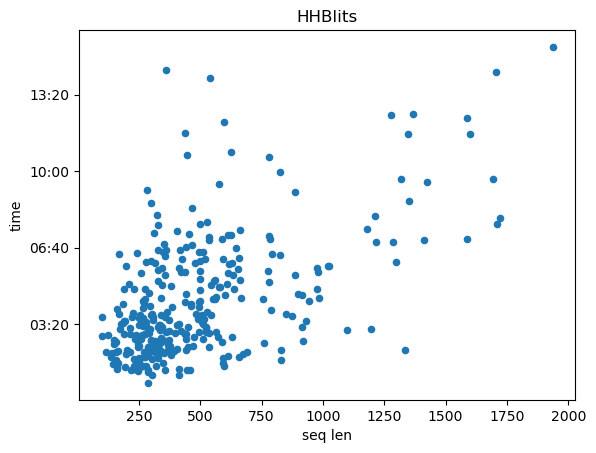

In [19]:
ax = times.loc[lambda x: x["time"] > datetime.timedelta(seconds=0)].plot.scatter("seq len", "time", title="HHBlits")
def nice_td(x, pos):
    td = pd.Timedelta(x)
    return f"{td.components.minutes:02d}:{td.components.seconds:02d}"

ax.yaxis.set_major_formatter(ticker.FuncFormatter(nice_td))

In [25]:
hhblits_times.loc[lambda x: x["time"] > datetime.timedelta(seconds=0)].sample(n=10).sort_values("seq len")

,seq len,time
464,193,0 days 00:03:28.596634
67,240,0 days 00:06:26.385954
127,275,0 days 00:02:53.363131
449,298,0 days 00:02:39.604554
298,301,0 days 00:02:18.546306
397,327,0 days 00:01:59.778930
448,364,0 days 00:02:10.306159
357,588,0 days 00:07:01.661905
100,1180,0 days 00:07:28.472109
66,1212,0 days 00:08:03.445663


In [20]:
times = []
for pdb in Path("../ensembles/pdb_ensemble/predictions").resolve().glob("*"):
    pkl = pdb / "features" / pdb.name / "HHBlitsF.pkl"
    if pkl.exists():
        res = pd.read_pickle(pkl)[0]
        times.append((len(res["result"]), datetime.timedelta(seconds=res["time"])))


for pdb in Path(".").resolve().glob("*"):
    for workdir in pdb.glob("*-2025-*"):
        pkl = pdb / "features" / pdb.name.split("-", 1)[0] / "HHBlitsF.pkl"
        if pkl.exists():
            res = pd.read_pickle(pkl)[0]
            times.append((len(res["result"]), datetime.timedelta(seconds=res["time"])))


times = pd.DataFrame(times, columns=["seq len", "time"])
mmseqs_times = times
times

,seq len,time
0,298,0 days 00:00:20.093666
1,297,0 days 00:00:19.925050
2,414,0 days 00:00:33.340655
3,298,0 days 00:00:20.003377
4,298,0 days 00:00:20.014333
...,...,...
115,298,0 days 00:00:20.130120
116,321,0 days 00:00:22.394931
117,356,0 days 00:00:22.164218
118,358,0 days 00:00:21.812380


In [21]:
import matplotlib.ticker as ticker

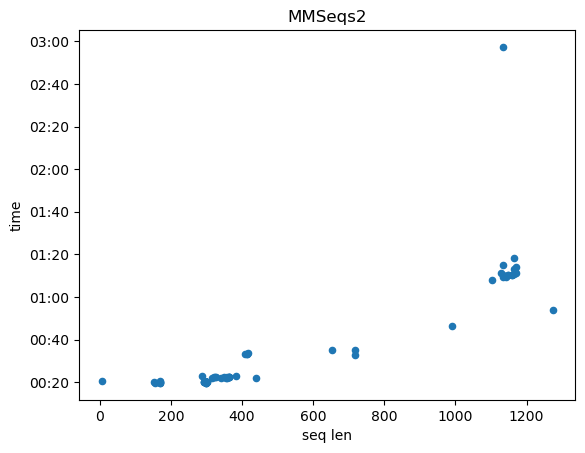

In [22]:
ax = times.loc[lambda x: x["time"] > datetime.timedelta(seconds=0)].plot.scatter("seq len", "time", title="MMSeqs2")
def nice_td(x, pos):
    td = pd.Timedelta(x)
    return f"{td.components.minutes:02d}:{td.components.seconds:02d}"

ax.yaxis.set_major_formatter(ticker.FuncFormatter(nice_td))

In [ ]:
dat

In [50]:
pd.read_pickle("8aq6/8aq6-G-2025-07-31-13-05-37-586371-inqfp744e9b/features/8aq6/HHBlitsF.pkl")

[{'pdb': '8aq6',
  'feature': 'hhblits',
  'result':     label_asym_id label_seq_id                    A    C    D  \
  0               G           11                  0.0  0.0  0.0   
  1               G           12                  0.0  0.0  0.0   
  2               G           13                  0.0  0.0  0.0   
  3               G           14                  0.0  0.0  0.0   
  4               G           15  0.23374379943786386  0.0  0.0   
  ..            ...          ...                  ...  ...  ...   
  166             G          177                  0.0  0.0  0.0   
  167             G          178                  0.0  0.0  0.0   
  168             G          179                  0.0  0.0  0.0   
  169             G          180                  0.0  0.0  0.0   
  170             G          181                  1.0  0.0  0.0   
  
                        E                   F                   G    H  \
  0                   0.0                 0.0  0.2733838643711581  0

# end

In [41]:
client = Client("http://127.0.0.1:8998/", download_files=False)

Loaded as API: http://127.0.0.1:8998/ ✔


In [42]:
job = client.submit(
        pdb={"text": "8aq6", "files": []},
        chainid="G", # {"pdb_id": pdb['text'], "chain_id": chain, "chain_choices": chain_choices, "pdbdir": pdbdir}
        api_name="/predict_ensemble",
    )

In [43]:
job.result()

8aq6-G-2025-11-24-18-25-57-281689-1645876784315941639 8aq6/8aq6-G-2025-07-31-13-05-37-586371-inqfp744e9b


()

In [45]:
job.exception() is None

True

In [7]:
import pandas as pd

In [15]:
mat = pd.read_csv("id.txt", skiprows=1, sep=" ", header=None, index_col=0)[1].to_dict()
mat

{'8aq6': 100.0, '5b0u': 95.027624, '7snr': 100.0}

In [ ]:
n = mat.shape[0]
tri_idx = np.tril_indices(n, k=-1)
mean_pid = mat[tri_idx].mean()
print("Mean pairwise identity:", mean_pid)

In [24]:
demo.close()

Closing server running on port: 8998


In [25]:
mvs_head = """
<script src="https://cdn.jsdelivr.net/npm/molstar@5.4.1/build/viewer/molstar.js"></script>
<link rel="stylesheet" href="https://cdn.jsdelivr.net/npm/molstar@5.4.1/build/viewer/molstar.css" />
<script>
  window.initMolstar = (function(){
    let promise;
    return function initMolstar(){
      if (promise) return promise;
      promise = new Promise(resolve => {
        (function wait(){
          if (window.molstar && window.molstar.Viewer && document.getElementById('viewer1')) {
            window.molstar.Viewer.create('viewer1',{layoutIsExpanded:false,layoutShowControls:false})
              .then(v => { window.MOLSTAR = {viewer: v, ready: promise}; resolve(v); })
              .catch(err => { promise = null; console.error('Mol* init failed', err); });
          } else requestAnimationFrame(wait);
        })();
      });
      return promise;
    };
  })();
</script>
"""

MSA_SPEC = """{
    "$schema": "https://unpkg.com/@genome-spy/core/dist/schema.json",
    "data": { "name": "msa" },
    "transform": [
      { "type": "flattenSequence", "field": "sequence" },
      {
        "type": "formula",
        "expr": "datum.sequence == '-' ? 'gap' : 'aa'",
        "as": "kind"
      }
    ],
    "encoding": {
      "x": {
        "field": "pos",
        "type": "index",
        "axis": { "title": "Position" },
        "scale": { "padding": 0.01 }
      },
      "y": {
        "field": "identifier",
        "type": "nominal",
        "axis": { "title": "Sequence" },
        "scale": {
          "paddingInner": 0.2,
          "paddingOuter": 0.05
        }
      }
    },
    "layer": [
      {
        "mark": "rect",
        "encoding": {
          "color": {
            "field": "kind",
            "type": "nominal",
            "scale": {
              "domain": ["gap", "aa"],
              "range": ["white", "#808080"]
            },
            "legend": null
          }
        }
      },
      {
        "opacity": {
          "channel": "x",
          "unitsPerPixel": [0.2, 0.05],
          "values": [0, 1]
        },
        "mark": {
          "type": "text",
          "fitToBand": true,
          "paddingX": 0,
          "paddingY": 0
        },
        "encoding": {
          "text": { "field": "sequence" },
          "color": { "value": "black" }
        }
      }
    ]
  }"""


# Minimal Gradio app that ensures window.showMsa exists synchronously and queues calls
import gradio as gr
import pandas as pd

genomespy_head = """
<script src="https://cdn.jsdelivr.net/npm/@genome-spy/core@0.63.0"></script>
<script>
  window.initGenomeSpy = (function () {
    let promise = null;
    return function initGenomeSpy() {
      if (promise) return promise;
      promise = new Promise((resolve, reject) => {
        (function wait() {
          const el = document.getElementById('msa-viewer');
          if (window.genomeSpyEmbed && el) {
            const maybe = genomeSpyEmbed.embed(el, {{MSA_SPEC}});
            Promise.resolve(maybe)
              .then(api => {
                window.GENOMESPY = { api, ready: promise };
                resolve(api);
              })
              .catch(err => {
                console.error("GenomeSpy init failed", err);
                promise = null;
                reject(err);
              });
          } else {
            requestAnimationFrame(wait);
          }
        })();
      });
      return promise;
    };
  })();
</script>
""".replace("{{MSA_SPEC}}", MSA_SPEC)


head = mvs_head + genomespy_head


genomespy_view = """
async (rows) => {
  try {
    const api = await window.initGenomeSpy?.();
    if (!api || typeof api.updateNamedData !== "function") return;
    api.updateNamedData("msa", Array.isArray(rows) ? rows : []);
  } catch (err) {
    console.error("GenomeSpy error:", err);
  }
}
"""


def load_tsv():
    return pd.read_csv("testaln.tsv", sep=",").to_dict("records")

with gr.Blocks(head=head) as demo:
    gr.Markdown("### GenomeSpy MSA minimal test")
    molstar = gr.HTML('<div id="viewer1" style="width:100%; height:400px"></div>')
    html_view = gr.HTML('<div id="msa-viewer" style="width:100%;"></div>')
    btn = gr.Button("Load local testaln.tsv")
    msa_rows = gr.JSON(visible=False)
    
    demo.load(
        fn=None, inputs=None, outputs=None, 
        js="() => window.initMolstar?.().catch(e => console.error('initMolstar failed', e))"
    )
    
    btn.click(load_tsv, outputs=msa_rows)
    msa_rows.change(fn=None, inputs=msa_rows, outputs=None, js=genomespy_view)

demo.launch(server_port=8998, show_error=True, debug=True)

* Running on local URL:  http://127.0.0.1:8998
* To create a public link, set `share=True` in `launch()`.


Keyboard interruption in main thread... closing server.


In [40]:
from gradio_client import Client, handle_file

client = Client("http://127.0.0.1:8998/", download_files=False)
result = client.submit(
        pdb={"text":"5npk","files":[]}, # handle_file("gradio/2ldr/2ldr-A-2025-07-29-13-50-02-571655-nta5oxepwpm/2ldr.cif")
        chainid="A",
        api_name="/predict"
)
# print(result)
result

Loaded as API: http://127.0.0.1:8998/ ✔


<Job at 0x7cf5f58d1010 state=running>

In [44]:
result.result()[1]

{'path': '/tmp/gradio/0c187ba02afa2e8fac38b8fb91c922d773bcdb417cfb9b084fd4fd647014b7ed/5npk-A-2025-11-21-14-53-17-352503-4829947949973553390.zip',
 'url': 'http://127.0.0.1:8998/gradio_api/file=/tmp/gradio/0c187ba02afa2e8fac38b8fb91c922d773bcdb417cfb9b084fd4fd647014b7ed/5npk-A-2025-11-21-14-53-17-352503-4829947949973553390.zip',
 'size': None,
 'orig_name': '5npk-A-2025-11-21-14-53-17-352503-4829947949973553390.zip',
 'mime_type': None,
 'is_stream': False,
 'meta': {'_type': 'gradio.FileData'}}

In [24]:
curl -X POST http://127.0.0.1:8998/gradio_api/call/predict -s -H "Content-Type: application/json" -d '{
	"data": [
							{"text":"8aq6","files":[]},
							"G"
	]}' \
	| awk -F'"' '{ print $4}'  \
	| read EVENT_ID; curl -N http://127.0.0.1:8998/gradio_api/call/predict/$EVENT_ID

SyntaxError: unterminated string literal (detected at line 2) (3813005529.py, line 2)